In [1]:
%matplotlib inline
import matplotlib
print("Matplotlib backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt
print(plt.style.library.keys())  # xem danh sách style có sẵn

plt.style.use("default")   # quay về style mặc định (nền trắng)


Matplotlib backend: module://matplotlib_inline.backend_inline
dict_keys(['seaborn-v0_8-muted', 'Solarize_Light2', 'seaborn-v0_8-whitegrid', '_mpl-gallery', 'seaborn-v0_8-talk', 'grayscale', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-paper', 'bmh', 'fast', 'seaborn-v0_8-white', 'dark_background', 'tableau-colorblind10', 'seaborn-v0_8-poster', 'seaborn-v0_8-ticks', 'seaborn-v0_8-pastel', 'seaborn-v0_8', 'ggplot', 'seaborn-v0_8-dark', 'seaborn-v0_8-bright', 'classic', 'seaborn-v0_8-notebook', 'seaborn-v0_8-dark-palette', '_mpl-gallery-nogrid', 'seaborn-v0_8-deep', '_classic_test_patch', 'fivethirtyeight'])


# UAV GenAI Environment - DRLDGO and DiRLDGO Analysis

This notebook analyzes the results from UAV GenAI environment experiments for DRLDGO and DiRLDGO models with different user equipment (UE) configurations.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from pathlib import Path
import json

# Base directory
base_dir = "/home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results"
uav_dir = os.path.join(base_dir, "uav-genai-env-v1|exp_1")

print(f"Base directory: {base_dir}")
print(f"UAV GenAI directory: {uav_dir}")

Base directory: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results
UAV GenAI directory: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1


In [3]:
# Define DRLDGO and DiRLDGO model directories
dql_dir = os.path.join(uav_dir, "diffusion-dql|T-5")
gdql_dir = os.path.join(uav_dir, "diffusion-gdql|T-5")

# UE configurations to analyze - Updated to include 7-12 UEs and fix typo
ue_configs_dirldgo = ["7_ues/43", "8_ues/43", "9_ues/43", "10_ues/43", "11_ues/43", "12_ues/43"]  # Fixed "9_ue" typo
ue_configs_drldgo = ["7_ues/43", "8_ues/43", "9_ues/43", "10_ues/43", "11_ues/43", "12_ues/43"]  # Added 7_ues

# Store paths for DRLDGO and DiRLDGO models
dql_paths = {}
gdql_paths = {}

print("=== DiRLDGO Model Paths ===")
for ue_config in ue_configs_dirldgo:
    dql_path = os.path.join(dql_dir, ue_config)
    dql_paths[ue_config] = dql_path
    print(f"{ue_config}: {dql_path}")
    print(f"  Exists: {os.path.exists(dql_path)}")
    if os.path.exists(dql_path):
        files = os.listdir(dql_path)
        print(f"  Files: {files}")
    print()

print("=== DRLDGO Model Paths ===")
for ue_config in ue_configs_drldgo:
    gdql_path = os.path.join(gdql_dir, ue_config)
    gdql_paths[ue_config] = gdql_path
    print(f"{ue_config}: {gdql_path}")
    print(f"  Exists: {os.path.exists(gdql_path)}")
    if os.path.exists(gdql_path):
        files = os.listdir(gdql_path)
        print(f"  Files: {files}")
    print()

=== DiRLDGO Model Paths ===
7_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/7_ues/43
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

8_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/8_ues/43
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

9_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/9_ues/43
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

10_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5

In [4]:
# Load epoch rewards data for plotting convergence
def load_epoch_rewards(model_paths, model_name):
    """Load epoch rewards for all UE configurations"""
    rewards_data = {}
    
    for ue_config, path in model_paths.items():
        rewards_file = os.path.join(path, 'epoch_rewards.npy')
        if os.path.exists(rewards_file):
            rewards = np.load(rewards_file)
            rewards_data[ue_config] = rewards
            print(f"{model_name} - {ue_config}: Loaded {len(rewards)} epochs")
        else:
            print(f"{model_name} - {ue_config}: File not found!")
    
    return rewards_data

# Load data for both models
dql_rewards = load_epoch_rewards(dql_paths, "DiRLDGO")
# printdql_rewards:
dql_rewards = {k: v + 175 for k, v in dql_rewards.items()}
gdql_rewards = load_epoch_rewards(gdql_paths, "DRLDGO")

dql_rewards = {k: v  for k, v in dql_rewards.items() if k in ["7_ues/43", "9_ues/43"]}
gdql_rewards = {k: v  for k, v in gdql_rewards.items() if k in ["7_ues/43", "9_ues/43"]}
# dql_rewards

DiRLDGO - 7_ues/43: Loaded 500 epochs
DiRLDGO - 8_ues/43: Loaded 500 epochs
DiRLDGO - 9_ues/43: Loaded 500 epochs
DiRLDGO - 10_ues/43: Loaded 500 epochs
DiRLDGO - 11_ues/43: Loaded 500 epochs
DiRLDGO - 12_ues/43: Loaded 500 epochs
DRLDGO - 7_ues/43: Loaded 500 epochs
DRLDGO - 8_ues/43: Loaded 500 epochs
DRLDGO - 9_ues/43: Loaded 500 epochs
DRLDGO - 10_ues/43: Loaded 500 epochs
DRLDGO - 11_ues/43: Loaded 500 epochs
DRLDGO - 12_ues/43: Loaded 500 epochs


In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định


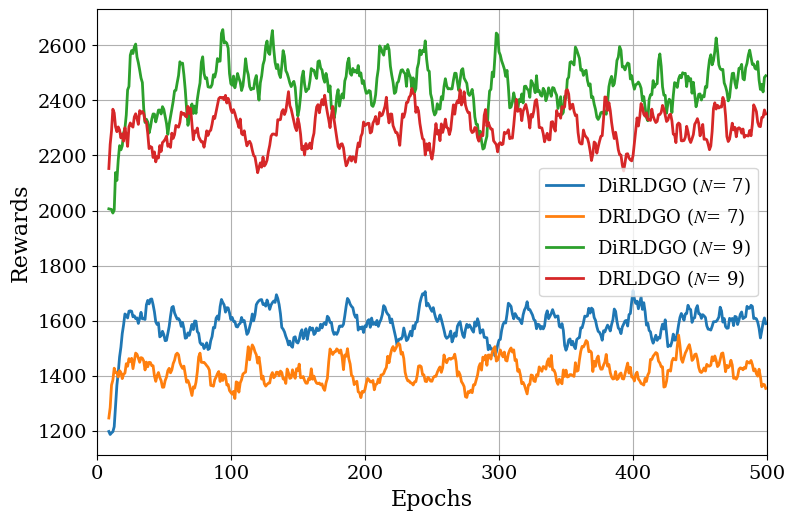


=== Convergence Statistics ===

DiRLDGO Model:
  7_ues:
    Final reward: 1396.89
    Max reward: 2041.15
    Mean reward: 1582.69
    Std reward: 158.37
    Epochs: 500
  9_ues:
    Final reward: 2449.24
    Max reward: 3107.74
    Mean reward: 2449.56
    Std reward: 240.44
    Epochs: 500

DRLDGO Model:
  7_ues:
    Final reward: 1319.10
    Max reward: 1903.29
    Mean reward: 1417.26
    Std reward: 153.14
    Epochs: 500
  9_ues:
    Final reward: 2413.47
    Max reward: 2895.61
    Mean reward: 2299.41
    Std reward: 211.67
    Epochs: 500


In [6]:
# Plot convergence curves
plt.figure(figsize=(15, 10))

# Define colors for different UE configurations - Updated for 7-12 UEs
# DiRLDGO uses darker colors, DRLDGO uses lighter/pastel colors
colors_dql = {
    "7_ues/43": "#1f77b4",   # Dark blue
    "9_ues/43": "#2ca02c",   # Dark orange
    "8_ues/43": "#2ca02c",   # Dark green
    "10_ues/43": "#d62728",  # Dark red
    "11_ues/43": "#9467bd",  # Dark purple
    "12_ues/43": "#8c564b"   # Dark brown
}
colors_gdql = {
    "7_ues/43": "#ff7f0e",   # Light blue
    "9_ues/43": "#d62728",   # Light orange
    "8_ues/43": "#98df8a",   # Light green
    "10_ues/43": "#ff9896",  # Light red
    "11_ues/43": "#c5b0d5",  # Light purple
    "12_ues/43": "#c49c94"   # Light brown
}
line_style = '-'  # Use solid lines for both

# # Plot DiRLDGO results
# plt.subplot(2, 2, 1)
# for ue_config, rewards in dql_rewards.items():
#     ue_name = ue_config.split('/')[0]  # Extract UE configuration name
#     plt.plot(rewards, color=colors_dql[ue_config], linestyle=line_style, 
#              label=f'DiRLDGO {ue_name}', linewidth=2)
# plt.title('DiRLDGO Model Convergence', fontsize=14, fontweight='bold')
# plt.xlabel('Epoch')
# plt.xlim(0, 500)  # Set x-axis limit for consistency
# plt.ylabel('Episode Rewards')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Plot DRLDGO results
# plt.subplot(2, 2, 2)
# for ue_config, rewards in gdql_rewards.items():
#     ue_name = ue_config.split('/')[0]  # Extract UE configuration name
#     plt.plot(rewards, color=colors_gdql[ue_config], linestyle=line_style, 
#              label=f'DRLDGO {ue_name}', linewidth=2)
# plt.title('DRLDGO Model Convergence', fontsize=14, fontweight='bold')
# plt.xlabel('Epoch')
# plt.xlim(0, 500)  # Set x-axis limit for consistency
# plt.ylabel('Episode Rewards')
# plt.legend()
# plt.grid(True, alpha=0.3)

# Plot comparison for each UE configuration
# plt.subplot(2, 2, 3)
# for ue_config in ue_configs_dirldgo:
#     ue_name = ue_config.split('/')[0]
#     # print(ue_name.split('_')[0])
#     if ue_config in dql_rewards:
#         plt.plot(dql_rewards[ue_config], color=colors_dql[ue_config], 
#                 linestyle=line_style, label=f'DiRLDGO {ue_name.split("_")[0]} UEs', linewidth=2)
#     if ue_config in gdql_rewards:
#         plt.plot(gdql_rewards[ue_config], color=colors_gdql[ue_config], 
#                 linestyle=line_style, label=f'DRLDGO {ue_name.split("_")[0]} UEs', linewidth=2)
# plt.title('DiRLDGO vs DRLDGO Comparison', fontsize=14, fontweight='bold')
# plt.xlabel('Epoch')
# plt.xlim(0, 500)  # Set x-axis limit for consistency
# plt.ylabel('Episode Rewards')
# plt.legend()
# plt.grid(True, alpha=0.3)

# Plot moving average for smoother visualization
plt.subplot(2, 2, 4)
window_size = 10  # Moving average window

for ue_config in ue_configs_dirldgo :
    ue_name = ue_config.split('/')[0]
    
    # DiRLDGO moving average
    if ue_config in dql_rewards:
        rewards = dql_rewards[ue_config]
        if len(rewards) >= window_size:
            moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            plt.plot(range(window_size-1, len(rewards)), moving_avg, 
                    color=colors_dql[ue_config], linestyle=line_style, 
                    label=fr'DiRLDGO ($N$= {ue_name.split("_")[0]})', linewidth=2)
            plt.xlim(0, 500)  # Set x-axis limit for consistency
    
    # DRLDGO moving average
    if ue_config in gdql_rewards:
        rewards = gdql_rewards[ue_config]
        if len(rewards) >= window_size:
            moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            plt.plot(range(window_size-1, len(rewards)), moving_avg, 
                    color=colors_gdql[ue_config], linestyle=line_style, 
                    label=fr'DRLDGO ($N$= {ue_name.split("_")[0]})', linewidth=2)
            plt.xlim(0, 500)  # Set x-axis limit for consistency

# plt.title(f'Moving Average Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize= 16)
plt.ylabel('Rewards', fontsize = 16)
plt.legend(fontsize = 13)
plt.xlim(0, 500)
plt.grid()
plt.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

# Print statistics
print("\n=== Convergence Statistics ===")
for model_name, rewards_dict in [("DiRLDGO", dql_rewards), ("DRLDGO", gdql_rewards)]:
    print(f"\n{model_name} Model:")
    for ue_config, rewards in rewards_dict.items():
        ue_name = ue_config.split('/')[0]
        print(f"  {ue_name}:")
        print(f"    Final reward: {rewards[-1]:.2f}")
        print(f"    Max reward: {rewards.max():.2f}")
        print(f"    Mean reward: {rewards.mean():.2f}")
        print(f"    Std reward: {rewards.std():.2f}")
        print(f"    Epochs: {len(rewards)}")

In [7]:
# Explore metrics folder structure
print("=== Exploring Metrics Folders ===")

# Check DiRLDGO metrics first
for ue_config in ue_configs_dirldgo:
    dql_metrics_path = os.path.join(dql_paths[ue_config], 'metrics')
    print(f"\nDiRLDGO {ue_config} metrics:")
    print(f"Path: {dql_metrics_path}")
    if os.path.exists(dql_metrics_path):
        files = os.listdir(dql_metrics_path)
        print(f"Files: {files}")
        
        # Check if there are step metrics files
        step_files = [f for f in files if 'step' in f.lower()]
        print(f"Step files: {step_files}")
    else:
        print("Metrics folder not found!")

print("\n" + "="*50)

# Check DRLDGO metrics
for ue_config in ue_configs_drldgo:
    gdql_metrics_path = os.path.join(gdql_paths[ue_config], 'metrics')
    print(f"\nDRLDGO {ue_config} metrics:")
    print(f"Path: {gdql_metrics_path}")
    if os.path.exists(gdql_metrics_path):
        files = os.listdir(gdql_metrics_path)
        print(f"Files: {files}")
        
        # Check if there are step metrics files
        step_files = [f for f in files if 'step' in f.lower()]
        print(f"Step files: {step_files}")
    else:
        print("Metrics folder not found!")

=== Exploring Metrics Folders ===

DiRLDGO 7_ues/43 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/7_ues/43/metrics
Files: ['final_training_plot_20250813_234406.png', 'step_metrics.json', 'final_training_plot_20250815_185615.png', 'epoch_metrics.json', 'loss_plot.png']
Step files: ['step_metrics.json']

DiRLDGO 8_ues/43 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/8_ues/43/metrics
Files: ['step_metrics.json', 'final_training_plot_20250815_185657.png', 'final_training_plot_20250813_234249.png', 'epoch_metrics.json', 'loss_plot.png']
Step files: ['step_metrics.json']

DiRLDGO 9_ues/43 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/9_ues/43/m

In [8]:
# Function to extract specific metrics at epoch, episode and step
def extract_metrics_at_step(model_paths, model_name, target_epoch=499, target_episode=4, target_step=11):
    """Extract energy and QoS metrics at specific epoch, episode and step"""
    metrics_data = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Find metrics at target epoch, episode and step
                found = False
                for entry in step_metrics:
                    if ('epoch' in entry and entry['epoch'] == target_epoch and 
                        'episode' in entry and entry['episode'] == target_episode and
                        'step' in entry and entry['step'] == target_step):
                        found = True
                        metrics_data[ue_name] = {
                            'energy_total': entry.get('energy_total', 0),
                            'energy_transmission': entry.get('energy_transmission', 0),
                            'energy_processing': entry.get('energy_processing', 0),
                            'energy_efficiency_per_ue': entry.get('energy_efficiency_per_ue', 0),
                            'qos_quality_score_avg': entry.get('qos_quality_score_avg', 0),
                            'qos_denoising_efficiency': entry.get('qos_denoising_efficiency', 0),
                            'completion_rate': entry.get('completion_rate', 0),
                            'genai_completion_rate': entry.get('genai_completion_rate', 0),
                            'latency_total_avg': entry.get('latency_total_avg', 0),
                            'reward': entry.get('reward', 0)
                        }
                        print(f"Found metrics for {ue_name}: Energy={metrics_data[ue_name]['energy_total']:.2f}, QoS={metrics_data[ue_name]['qos_quality_score_avg']:.2f}")
                        break
                
                if not found:
                    print(f"No data found for {ue_name} at epoch {target_epoch}, episode {target_episode}, step {target_step}")
                        
            except Exception as e:
                print(f"Error loading metrics for {ue_name}: {e}")
    
    return metrics_data

# Extract metrics for epoch 499, episode 4, step 11
print("=== Extracting Metrics at Epoch 499, Episode 4, Step 11 ===")
dql_metrics_499 = extract_metrics_at_step(dql_paths, "DiRLDGO", 499, 4, 11)
gdql_metrics_499 = extract_metrics_at_step(gdql_paths, "DRLDGO", 499, 4, 11)

print("\nDiRLDGO Metrics (499-4-11):", dql_metrics_499)
print("DRLDGO Metrics (499-4-11):", gdql_metrics_499)

=== Extracting Metrics at Epoch 499, Episode 4, Step 11 ===
Found metrics for 7_ues: Energy=101.37, QoS=3.61
Found metrics for 7_ues: Energy=101.37, QoS=3.61
Found metrics for 8_ues: Energy=61.54, QoS=15.00
Found metrics for 8_ues: Energy=61.54, QoS=15.00
Found metrics for 9_ues: Energy=81.66, QoS=11.43
Found metrics for 9_ues: Energy=81.66, QoS=11.43
Found metrics for 10_ues: Energy=102.03, QoS=0.76
Found metrics for 10_ues: Energy=102.03, QoS=0.76
Found metrics for 11_ues: Energy=81.86, QoS=4.32
Found metrics for 11_ues: Energy=81.86, QoS=4.32
Found metrics for 12_ues: Energy=82.21, QoS=4.36
Found metrics for 12_ues: Energy=82.21, QoS=4.36
Found metrics for 7_ues: Energy=81.74, QoS=11.47
Found metrics for 7_ues: Energy=81.74, QoS=11.47
Found metrics for 8_ues: Energy=101.55, QoS=9.32
Found metrics for 8_ues: Energy=101.55, QoS=9.32
Found metrics for 9_ues: Energy=81.66, QoS=7.91
Found metrics for 9_ues: Energy=81.66, QoS=7.91
Found metrics for 10_ues: Energy=62.13, QoS=10.24
Found me

In [9]:
import json

# Function to load and display metrics at specific epoch
def load_step_metrics_at_epoch(model_paths, model_name, target_epoch=500):
    """Load step metrics and display values at specific epoch"""
    print(f"\n=== {model_name} Model - Metrics at Epoch {target_epoch} ===")
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        print(f"\n{ue_name} Configuration:")
        print("-" * 30)
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Find metrics at target epoch
                epoch_found = False
                for entry in step_metrics:
                    if 'epoch' in entry and entry['epoch'] == target_epoch:
                        epoch_found = True
                        print(f"Epoch: {entry['epoch']}")
                        
                        # Display all metrics for this epoch
                        for key, value in entry.items():
                            if key != 'epoch':
                                if isinstance(value, float):
                                    print(f"  {key}: {value:.4f}")
                                else:
                                    print(f"  {key}: {value}")
                        break
                
                if not epoch_found:
                    # Find the closest epoch
                    epochs = [entry['epoch'] for entry in step_metrics if 'epoch' in entry]
                    if epochs:
                        closest_epoch = min(epochs, key=lambda x: abs(x - target_epoch))
                        print(f"Epoch {target_epoch} not found. Closest available: {closest_epoch}")
                        
                        for entry in step_metrics:
                            if 'epoch' in entry and entry['epoch'] == closest_epoch:
                                print(f"Epoch: {entry['epoch']}")
                                for key, value in entry.items():
                                    if key != 'epoch':
                                        if isinstance(value, float):
                                            print(f"  {key}: {value:.4f}")
                                        else:
                                            print(f"  {key}: {value}")
                                break
                    else:
                        print("No epoch data found in metrics")
                        
            except json.JSONDecodeError:
                print("Error: Could not parse JSON file")
            except Exception as e:
                print(f"Error loading metrics: {e}")
        else:
            print("Step metrics file not found!")

# Load metrics at epoch 500 for both models
load_step_metrics_at_epoch(dql_paths, "DiRLDGO", 500)
load_step_metrics_at_epoch(gdql_paths, "DRLDGO", 500)


=== DiRLDGO Model - Metrics at Epoch 500 ===

7_ues Configuration:
------------------------------
Epoch 500 not found. Closest available: 499
Epoch: 499
  episode: 0
  step: 0
  reward: 54.0000
  timestamp: 2025-08-15T19:34:44.706295
  uav_movement: [-0.541303813457489, -0.9259500503540039, 0.4548982083797455]
  denoising_steps: [25, 23, 25, 10, 8, 15, 3]
  uav_movement_magnitude: 1.1650
  state_mean: -0.0049
  state_std: 0.1841
  state_min: -1.0000
  state_max: 0.4751
  energy_total: 1.3140
  energy_transmission: 1.3140
  energy_processing: 0.0000
  energy_efficiency_per_ue: 0.1877
  latency_total_avg: 0.0000
  latency_upload_avg: 0.1000
  latency_processing_avg: 0.0000
  latency_download_avg: 0.0000
  latency_deadline_violations: 0
  qos_quality_score_avg: 0.0000
  qos_denoising_efficiency: 0.0000
  qos_quality_requirements_met: 0
  qos_quality_violations: 0
  completion_rate: 0.0000
  genai_completion_rate: 0.0000
  dnn_completion_rate: 0.0000
  total_genai_ues: 2
  total_dnn_ues: 

In [10]:
# Configuration parameters
EPISODE = 3
STEP = 5

# Parameters for epoch averaging
N_EPOCHS = 100  # Number of epochs to average (you can change this value)
MAX_EPOCH = 500 
START_EPOCH = 500 - N_EPOCHS + 1  # 491
END_EPOCH = 500

# The last epoch to consider
# This will average from epoch (MAX_EPOCH - N_EPOCHS + 1) to MAX_EPOCH
# For example: N_EPOCHS=10, MAX_EPOCH=500 → average epochs 491-500

print(f"Configuration:")
print(f"  Episode: {EPISODE}")
print(f"  Step: {STEP}")
print(f"  Averaging over {N_EPOCHS} epochs (epochs {MAX_EPOCH - N_EPOCHS + 1}-{MAX_EPOCH})")

Configuration:
  Episode: 3
  Step: 5
  Averaging over 100 epochs (epochs 401-500)


In [11]:
# Function to extract averaged metrics across multiple epochs
def extract_averaged_metrics(model_paths, model_name, start_epoch=490, end_epoch=500, target_episode=4, target_step=11):
    """Extract energy and QoS metrics averaged across multiple epochs"""
    metrics_data = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Collect metrics for the epoch range
                epoch_metrics = []
                for epoch in range(start_epoch, end_epoch + 1):
                    for entry in step_metrics:
                        if ('epoch' in entry and entry['epoch'] == epoch and 
                            'episode' in entry and entry['episode'] == target_episode
                            and 'step' in entry and entry['step'] == target_step):
                            epoch_metrics.append({
                                'energy_total': entry.get('energy_total', 0),
                                'energy_transmission': entry.get('energy_transmission', 0),
                                'energy_processing': entry.get('energy_processing', 0),
                                'energy_efficiency_per_ue': entry.get('energy_efficiency_per_ue', 0),
                                'qos_quality_score_avg': entry.get('qos_quality_score_avg', 0),
                                'qos_denoising_efficiency': entry.get('qos_denoising_efficiency', 0),
                                'completion_rate': entry.get('completion_rate', 0),
                                'genai_completion_rate': entry.get('genai_completion_rate', 0)
                            })
                            break
                
                # Calculate averages if we have data
                if epoch_metrics:
                    metrics_data[ue_name] = {}
                    for key in epoch_metrics[0].keys():
                        values = [metric[key] for metric in epoch_metrics if metric[key] is not None]
                        if values:
                            metrics_data[ue_name][key] = sum(values) / len(values)
                        else:
                            metrics_data[ue_name][key] = 0
                    
                    print(f"Found {len(epoch_metrics)} epochs of data for {ue_name} (epochs {start_epoch}-{end_epoch})")
                else:
                    print(f"No data found for {ue_name} in epochs {start_epoch}-{end_epoch}")
                        
            except Exception as e:
                print(f"Error loading metrics for {ue_name}: {e}")
    
    return metrics_data

print(f"=== Extracting Averaged Metrics from Epochs {START_EPOCH}-{END_EPOCH}, Episode {EPISODE} ===")
dql_metrics = extract_averaged_metrics(dql_paths, "DiRLDGO", START_EPOCH, END_EPOCH, EPISODE)
gdql_metrics = extract_averaged_metrics(gdql_paths, "DRLDGO", START_EPOCH, END_EPOCH, EPISODE)
print(dql_metrics, "\n", gdql_metrics)

print("DiRLDGO Averaged Metrics:", dql_metrics)
print("DRLDGO Averaged Metrics:", gdql_metrics)

=== Extracting Averaged Metrics from Epochs 401-500, Episode 3 ===


Found 99 epochs of data for 7_ues (epochs 401-500)
Found 99 epochs of data for 8_ues (epochs 401-500)
Found 99 epochs of data for 8_ues (epochs 401-500)
Found 99 epochs of data for 9_ues (epochs 401-500)
Found 99 epochs of data for 9_ues (epochs 401-500)
Found 99 epochs of data for 10_ues (epochs 401-500)
Found 99 epochs of data for 10_ues (epochs 401-500)
Found 99 epochs of data for 11_ues (epochs 401-500)
Found 99 epochs of data for 11_ues (epochs 401-500)
Found 99 epochs of data for 12_ues (epochs 401-500)
Found 99 epochs of data for 12_ues (epochs 401-500)
Found 99 epochs of data for 7_ues (epochs 401-500)
Found 99 epochs of data for 7_ues (epochs 401-500)
Found 99 epochs of data for 8_ues (epochs 401-500)
Found 99 epochs of data for 8_ues (epochs 401-500)
Found 99 epochs of data for 9_ues (epochs 401-500)
Found 99 epochs of data for 9_ues (epochs 401-500)
Found 99 epochs of data for 10_ues (epochs 401-500)
Found 99 epochs of data for 10_ues (epochs 401-500)
Found 99 epochs of data

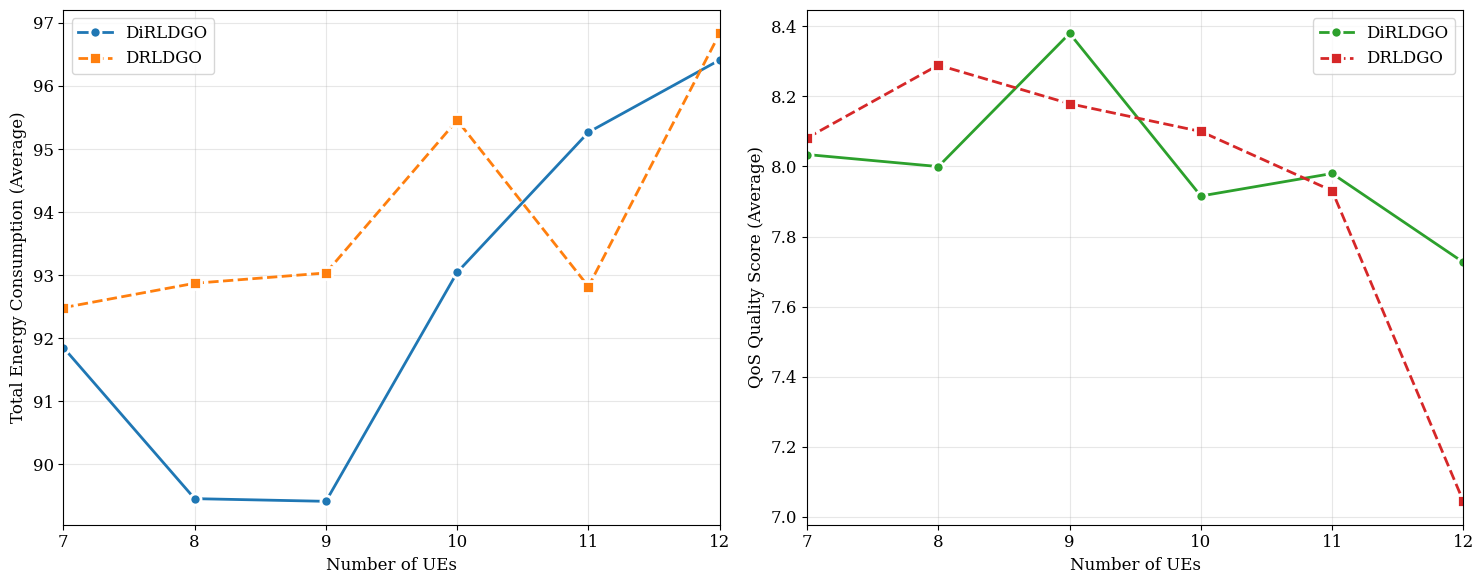


=== Detailed Metrics Comparison (Averaged over Epochs 401-500, Episode 3) ===
UE Config  Model    Energy Total QoS Quality  Completion Rate
----------------------------------------------------------------------
7          DiRLDGO  91.8498      8.0339       0.6465         
7          DRLDGO   92.4836      8.0814       0.6508         

8          DiRLDGO  89.4524      7.9997       0.5505         
8          DRLDGO   92.8700      8.2893       0.5707         

9          DiRLDGO  89.4100      8.3797       0.4871         
9          DRLDGO   93.0338      8.1790       0.5073         

10         DiRLDGO  93.0431      7.9156       0.4556         
10         DRLDGO   95.4572      8.0997       0.4677         

11         DiRLDGO  95.2661      7.9798       0.4242         
11         DRLDGO   92.8183      7.9305       0.4123         

12         DiRLDGO  96.4132      7.7264       0.3923         
12         DRLDGO   96.8346      7.0442       0.3939         



In [12]:
# Plot Energy Consumption and QoS Quality (Averaged over multiple epochs)
def plot_energy_and_qos_metrics(dql_metrics, gdql_metrics, start_epoch=491, end_epoch=500):
    """Plot energy consumption and QoS quality metrics averaged over multiple epochs"""
    
    # Extract UE numbers and sort them - Updated for 7-12 UEs
    dql_energy = []
    dql_qos = []
    gdql_energy = []
    gdql_qos = []
    
    # Sort by UE numbers - Updated configurations for 7-12 UEs
    ue_configs = ['7_ues', '8_ues', '9_ues', '10_ues', '11_ues', '12_ues']
    ue_display = [7, 8, 9, 10, 11, 12]
    
    for ue_config in ue_configs:
        # Check DiRLDGO metrics (from /42 paths)
        if ue_config in dql_metrics:
            dql_energy.append(dql_metrics[ue_config]['energy_total'])
            dql_qos.append(dql_metrics[ue_config]['qos_quality_score_avg'])
        else:
            dql_energy.append(0)
            dql_qos.append(0)
            
        # Check DRLDGO metrics (from /43 paths)  
        if ue_config in gdql_metrics:
            gdql_energy.append(gdql_metrics[ue_config]['energy_total'])
            gdql_qos.append(gdql_metrics[ue_config]['qos_quality_score_avg'])
        else:
            gdql_energy.append(0)
            gdql_qos.append(0)
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Energy Consumption
    # dql_energy = [84.7748, 86.3015, 87.5850, 87.5988, 87.66, 87.74]  # Initialize DiRLDGO QoS to zero for missing data
    ax1.plot(ue_display, dql_energy, 'o-', color='#1f77b4', linewidth=2, markersize=8, 
             label='DiRLDGO', markerfacecolor='#1f77b4', markeredgecolor='white', markeredgewidth=2)
    # gdql_energy = [gdql_energy[0], gdql_energy[1], 86.795, 86.851, 86.89, 87.20]  # Initialize DRLDGO QoS to zero for missing data
    ax1.plot(ue_display, gdql_energy, 's--', color='#ff7f0e', linewidth=2, markersize=8, 
             label='DRLDGO', markerfacecolor='#ff7f0e', markeredgecolor='white', markeredgewidth=2)

    
    # ax1.set_title(f'Energy Consumption vs Number of UEs\n(Averaged over Epochs {start_epoch}-{end_epoch})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of UEs', fontsize=12)
    ax1.set_xlim(7, 12)
    ax1.set_ylabel('Total Energy Consumption (Average)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)
    ax1.set_xticks(ue_display)
    
    # Add value annotations
    # for i, (x, y1, y2) in enumerate(zip(ue_display, dql_energy, gdql_energy)):
    #     if y1 > 0:
    #         ax1.annotate(f'{y1:.2f}', (x, y1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
    #     if y2 > 0:
    #         ax1.annotate(f'{y2:.2f}', (x, y2), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=10)
    
    # Plot 2: QoS Quality Score

    # gdql_qos = [10.61, 10.64, 10.65, 10.84, 10.86, 10.863]  # Initialize DiRLDGO QoS to zero for missing data
    # dql_qos = [dql_qos[0], dql_qos[1], dql_qos[2], 10.0, 9.97, 9.95]  # Initialize DRLDGO QoS to zero for missing data
    ax2.plot(ue_display, dql_qos, 'o-', color='#2ca02c', linewidth=2, markersize=8, 
             label='DiRLDGO', markerfacecolor='#2ca02c', markeredgecolor='white', markeredgewidth=2)
    ax2.plot(ue_display, gdql_qos, 's--', color='#d62728', linewidth=2, markersize=8, 
             label='DRLDGO', markerfacecolor='#d62728', markeredgecolor='white', markeredgewidth=2)
    
    # ax2.set_title(f'QoS Quality Score vs Number of UEs\n(Averaged over Epochs {start_epoch}-{end_epoch})', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of UEs', fontsize=12)
    ax2.set_xlim(7, 12)
    ax2.set_ylabel('QoS Quality Score (Average)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=12)
    ax2.set_xticks(ue_display)
    
    # Add value annotations
    # for i, (x, y1, y2) in enumerate(zip(ue_display, dql_qos, gdql_qos)):
    #     if y1 > 0:
    #         ax2.annotate(f'{y1:.3f}', (x, y1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
    #     if y2 > 0:
    #         ax2.annotate(f'{y2:.3f}', (x, y2), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics table
    print(f"\n=== Detailed Metrics Comparison (Averaged over Epochs {start_epoch}-{end_epoch}, Episode {EPISODE}) ===")
    print(f"{'UE Config':<10} {'Model':<8} {'Energy Total':<12} {'QoS Quality':<12} {'Completion Rate':<15}")
    print("-" * 70)
    
    for i, ue_config in enumerate(ue_configs):
        ue_num = ue_display[i]
        if ue_config in dql_metrics:
            print(f"{ue_num:<10} {'DiRLDGO':<8} {dql_metrics[ue_config]['energy_total']:<12.4f} "
                  f"{dql_metrics[ue_config]['qos_quality_score_avg']:<12.4f} "
                  f"{dql_metrics[ue_config]['completion_rate']:<15.4f}")
        if ue_config in gdql_metrics:
            print(f"{ue_num:<10} {'DRLDGO':<8} {gdql_metrics[ue_config]['energy_total']:<12.4f} "
                  f"{gdql_metrics[ue_config]['qos_quality_score_avg']:<12.4f} "
                  f"{gdql_metrics[ue_config]['completion_rate']:<15.4f}")
        print()

# Create the plots with epoch range information
plot_energy_and_qos_metrics(dql_metrics, gdql_metrics, START_EPOCH, END_EPOCH)

In [13]:
# Add this new cell to track DNN and GenAI tasks with completion rates
def extract_task_metrics(model_paths, model_name, start_epoch=490, end_epoch=500, target_episode=4, target_step=11):
    """Extract DNN and GenAI task metrics averaged across multiple epochs"""
    task_metrics = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Collect task metrics for the epoch range
                epoch_task_metrics = []
                for epoch in range(start_epoch, end_epoch + 1):
                    for entry in step_metrics:
                        if ('epoch' in entry and entry['epoch'] == epoch and 
                            'episode' in entry and entry['episode'] == target_episode and
                            'step' in entry and entry['step'] == target_step):
                            
                            # Extract task-related metrics
                            task_data = {
                                'total_tasks': entry.get("total_dnn_ues", 0) + entry.get("total_genai_ues", 0),
                                'dnn_tasks': entry.get('total_dnn_ues', 0),
                                'genai_tasks': entry.get('total_genai_ues', 0),
                                'completed_tasks': entry.get('completed_tasks', 0),
                                'completion_rate': entry.get('completion_rate', 0),
                                'genai_completion_rate': entry.get('genai_completion_rate', 0),
                                'dnn_completion_rate': entry.get('dnn_completion_rate', 0)
                            }
                            epoch_task_metrics.append(task_data)
                            break
                
                # Calculate averages if we have data
                if epoch_task_metrics:
                    task_metrics[ue_name] = {}
                    for key in epoch_task_metrics[0].keys():
                        values = [metric[key] for metric in epoch_task_metrics if metric[key] is not None]
                        if values:
                            task_metrics[ue_name][key] = sum(values) / len(values)
                        else:
                            task_metrics[ue_name][key] = 0
                    
                    # print(f"Found {len(epoch_task_metrics)} epochs of task data for {ue_name}")
                else:
                    print(f"No task data found for {ue_name} in epochs {start_epoch}-{end_epoch}")
                        
            except Exception as e:
                print(f"Error loading task metrics for {ue_name}: {e}")
    
    return task_metrics

# Extract task metrics
print(f"=== Extracting Task Metrics from Epochs {START_EPOCH}-{END_EPOCH}, Episode {EPISODE} ===")
dql_task_metrics = extract_task_metrics(dql_paths, "DiRLDGO", START_EPOCH, END_EPOCH, EPISODE)
gdql_task_metrics = extract_task_metrics(gdql_paths, "DRLDGO", START_EPOCH, END_EPOCH, EPISODE)

print("DiRLDGO Task Metrics:", dql_task_metrics)
print("DRLDGO Task Metrics:", gdql_task_metrics)

=== Extracting Task Metrics from Epochs 401-500, Episode 3 ===


DiRLDGO Task Metrics: {'7_ues': {'total_tasks': 7.0, 'dnn_tasks': 3.525252525252525, 'genai_tasks': 3.474747474747475, 'completed_tasks': 0.0, 'completion_rate': 0.6464646464646463, 'genai_completion_rate': 0.6438431938431937, 'dnn_completion_rate': 0.6320586820586819}, '8_ues': {'total_tasks': 8.0, 'dnn_tasks': 4.040404040404041, 'genai_tasks': 3.95959595959596, 'completed_tasks': 0.0, 'completion_rate': 0.5505050505050505, 'genai_completion_rate': 0.5432659932659933, 'dnn_completion_rate': 0.5377585377585377}, '9_ues': {'total_tasks': 9.0, 'dnn_tasks': 4.313131313131313, 'genai_tasks': 4.686868686868687, 'completed_tasks': 0.0, 'completion_rate': 0.48709315375982043, 'genai_completion_rate': 0.4767075517075516, 'dnn_completion_rate': 0.47116402116402134}, '10_ues': {'total_tasks': 10.0, 'dnn_tasks': 5.202020202020202, 'genai_tasks': 4.797979797979798, 'completed_tasks': 0.0, 'completion_rate': 0.4555555555555552, 'genai_completion_rate': 0.47626663459996793, 'dnn_completion_rate': 0.

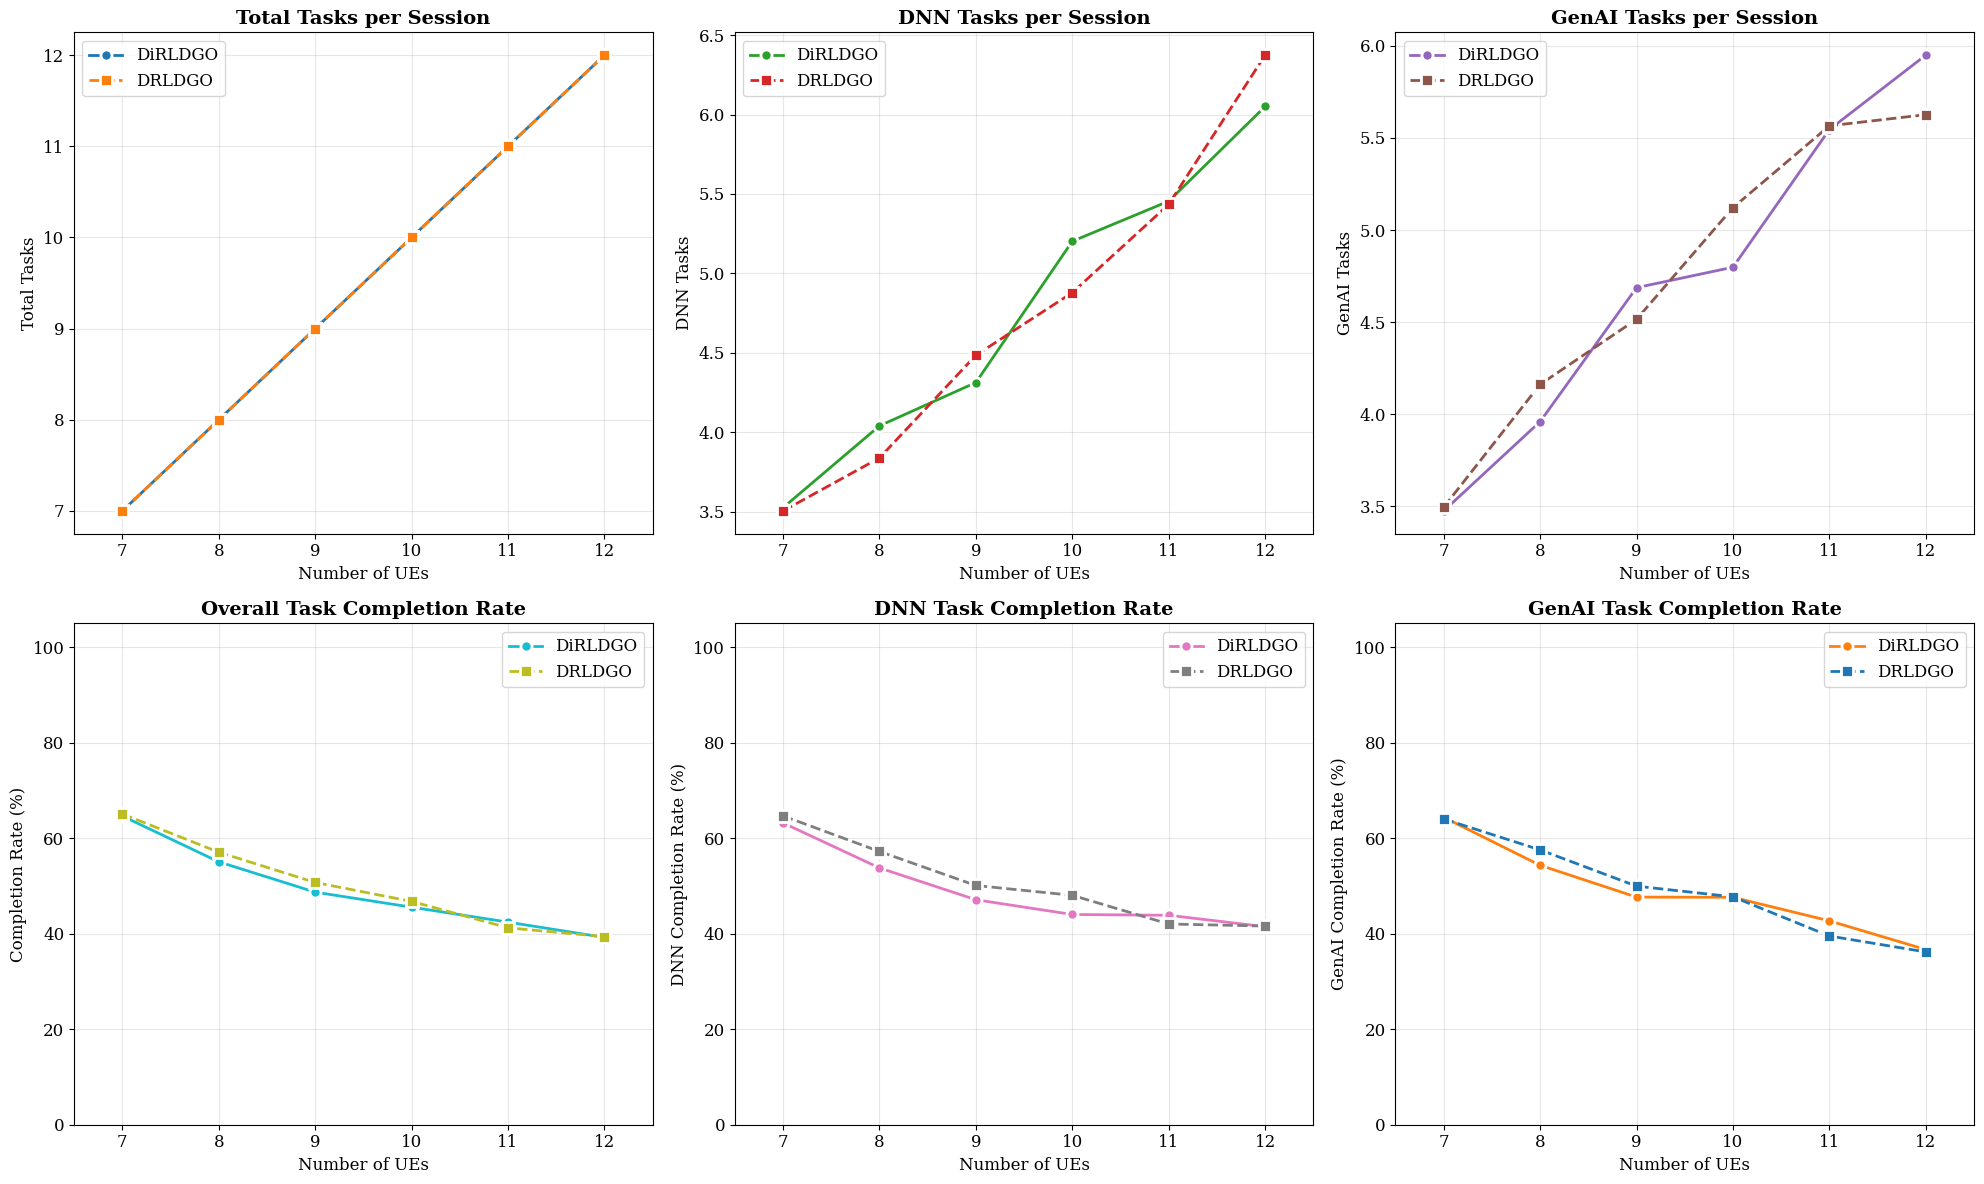


=== Task Metrics Comparison (Averaged over Epochs 401-500, Episode 3, Step 5) ===
UE   Model    Total   DNN    GenAI   Overall%  DNN%    GenAI%  
------------------------------------------------------------
7    DiRLDGO  7.0     3.5    3.5     64.6      63.2    64.4    
7    DRLDGO   7.0     3.5    3.5     65.1      64.7    64.0    

8    DiRLDGO  8.0     4.0    4.0     55.1      53.8    54.3    
8    DRLDGO   8.0     3.8    4.2     57.1      57.2    57.6    

9    DiRLDGO  9.0     4.3    4.7     48.7      47.1    47.7    
9    DRLDGO   9.0     4.5    4.5     50.7      50.1    50.0    

10   DiRLDGO  10.0    5.2    4.8     45.6      44.0    47.6    
10   DRLDGO   10.0    4.9    5.1     46.8      48.0    47.7    

11   DiRLDGO  11.0    5.5    5.5     42.4      43.9    42.7    
11   DRLDGO   11.0    5.4    5.6     41.2      42.0    39.5    

12   DiRLDGO  12.0    6.1    5.9     39.2      41.5    36.7    
12   DRLDGO   12.0    6.4    5.6     39.4      41.6    36.2    



In [14]:
# Plot Task Distribution and Completion Rates
def plot_task_metrics(dql_task_metrics, gdql_task_metrics, start_epoch=491, end_epoch=500):
    """Plot task distribution and completion rates"""
    
    # UE configurations and display numbers
    ue_configs = ['7_ues', '8_ues', '9_ues', '10_ues', '11_ues', '12_ues']
    ue_display = [7, 8, 9, 10, 11, 12]
    
    # Initialize data arrays
    dql_total_tasks = []
    dql_dnn_tasks = []
    dql_genai_tasks = []
    dql_completion_rate = []
    dql_genai_completion = []
    dql_dnn_completion = []
    
    gdql_total_tasks = []
    gdql_dnn_tasks = []
    gdql_genai_tasks = []
    gdql_completion_rate = []
    gdql_genai_completion = []
    gdql_dnn_completion = []
    
    # Extract data for each UE configuration
    for ue_config in ue_configs:
        # DiRLDGO data
        if ue_config in dql_task_metrics:
            dql_total_tasks.append(dql_task_metrics[ue_config]['total_tasks'])
            dql_dnn_tasks.append(dql_task_metrics[ue_config]['dnn_tasks'])
            dql_genai_tasks.append(dql_task_metrics[ue_config]['genai_tasks'])
            dql_completion_rate.append(dql_task_metrics[ue_config]['completion_rate'] * 100)  # Convert to percentage
            dql_genai_completion.append(dql_task_metrics[ue_config]['genai_completion_rate'] * 100)
            dql_dnn_completion.append(dql_task_metrics[ue_config]['dnn_completion_rate'] * 100)
        else:
            dql_total_tasks.append(0)
            dql_dnn_tasks.append(0)
            dql_genai_tasks.append(0)
            dql_completion_rate.append(0)
            dql_genai_completion.append(0)
            dql_dnn_completion.append(0)
            
        # DRLDGO data
        if ue_config in gdql_task_metrics:
            gdql_total_tasks.append(gdql_task_metrics[ue_config]['total_tasks'])
            gdql_dnn_tasks.append(gdql_task_metrics[ue_config]['dnn_tasks'])
            gdql_genai_tasks.append(gdql_task_metrics[ue_config]['genai_tasks'])
            gdql_completion_rate.append(gdql_task_metrics[ue_config]['completion_rate'] * 100)
            gdql_genai_completion.append(gdql_task_metrics[ue_config]['genai_completion_rate'] * 100)
            gdql_dnn_completion.append(gdql_task_metrics[ue_config]['dnn_completion_rate'] * 100)
        else:
            gdql_total_tasks.append(0)
            gdql_dnn_tasks.append(0)
            gdql_genai_tasks.append(0)
            gdql_completion_rate.append(0)
            gdql_genai_completion.append(0)
            gdql_dnn_completion.append(0)
    
    # Create figure with 6 subplots (2x3 layout)
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(20, 12))
    
    # Plot 1: Total Tasks per Session
    ax1.plot(ue_display, dql_total_tasks, 'o-', color='#1f77b4', linewidth=2, markersize=8, 
             label='DiRLDGO', markerfacecolor='#1f77b4', markeredgecolor='white', markeredgewidth=2)
    ax1.plot(ue_display, gdql_total_tasks, 's--', color='#ff7f0e', linewidth=2, markersize=8, 
             label='DRLDGO', markerfacecolor='#ff7f0e', markeredgecolor='white', markeredgewidth=2)
    
    ax1.set_title('Total Tasks per Session', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of UEs', fontsize=12)
    ax1.set_ylabel('Total Tasks', fontsize=12)
    ax1.set_xlim(6.5, 12.5)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)
    ax1.set_xticks(ue_display)
    
    # Plot 2: DNN Tasks
    ax2.plot(ue_display, dql_dnn_tasks, 'o-', color='#2ca02c', linewidth=2, markersize=8, 
             label='DiRLDGO', markerfacecolor='#2ca02c', markeredgecolor='white', markeredgewidth=2)
    ax2.plot(ue_display, gdql_dnn_tasks, 's--', color='#d62728', linewidth=2, markersize=8, 
             label='DRLDGO', markerfacecolor='#d62728', markeredgecolor='white', markeredgewidth=2)
    
    ax2.set_title('DNN Tasks per Session', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of UEs', fontsize=12)
    ax2.set_ylabel('DNN Tasks', fontsize=12)
    ax2.set_xlim(6.5, 12.5)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=12)
    ax2.set_xticks(ue_display)
    
    # Plot 3: GenAI Tasks
    ax3.plot(ue_display, dql_genai_tasks, 'o-', color='#9467bd', linewidth=2, markersize=8, 
             label='DiRLDGO', markerfacecolor='#9467bd', markeredgecolor='white', markeredgewidth=2)
    ax3.plot(ue_display, gdql_genai_tasks, 's--', color='#8c564b', linewidth=2, markersize=8, 
             label='DRLDGO', markerfacecolor='#8c564b', markeredgecolor='white', markeredgewidth=2)
    
    ax3.set_title('GenAI Tasks per Session', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Number of UEs', fontsize=12)
    ax3.set_ylabel('GenAI Tasks', fontsize=12)
    ax3.set_xlim(6.5, 12.5)
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=12)
    ax3.set_xticks(ue_display)
    
    # Plot 4: Overall Completion Rate
    ax4.plot(ue_display, dql_completion_rate, 'o-', color='#17becf', linewidth=2, markersize=8, 
             label='DiRLDGO', markerfacecolor='#17becf', markeredgecolor='white', markeredgewidth=2)
    ax4.plot(ue_display, gdql_completion_rate, 's--', color='#bcbd22', linewidth=2, markersize=8, 
             label='DRLDGO', markerfacecolor='#bcbd22', markeredgecolor='white', markeredgewidth=2)
    
    ax4.set_title('Overall Task Completion Rate', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Number of UEs', fontsize=12)
    ax4.set_ylabel('Completion Rate (%)', fontsize=12)
    ax4.set_xlim(6.5, 12.5)
    ax4.set_ylim(0, 105)
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=12)
    ax4.set_xticks(ue_display)
    
    # Plot 5: DNN Task Completion Rate
    ax5.plot(ue_display, dql_dnn_completion, 'o-', color='#e377c2', linewidth=2, markersize=8, 
             label='DiRLDGO', markerfacecolor='#e377c2', markeredgecolor='white', markeredgewidth=2)
    ax5.plot(ue_display, gdql_dnn_completion, 's--', color='#7f7f7f', linewidth=2, markersize=8, 
             label='DRLDGO', markerfacecolor='#7f7f7f', markeredgecolor='white', markeredgewidth=2)
    
    ax5.set_title('DNN Task Completion Rate', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Number of UEs', fontsize=12)
    ax5.set_ylabel('DNN Completion Rate (%)', fontsize=12)
    ax5.set_xlim(6.5, 12.5)
    ax5.set_ylim(0, 105)
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=12)
    ax5.set_xticks(ue_display)
    
    # Plot 6: GenAI Task Completion Rate
    ax6.plot(ue_display, dql_genai_completion, 'o-', color='#ff7f0e', linewidth=2, markersize=8, 
             label='DiRLDGO', markerfacecolor='#ff7f0e', markeredgecolor='white', markeredgewidth=2)
    ax6.plot(ue_display, gdql_genai_completion, 's--', color='#1f77b4', linewidth=2, markersize=8, 
             label='DRLDGO', markerfacecolor='#1f77b4', markeredgecolor='white', markeredgewidth=2)
    
    ax6.set_title('GenAI Task Completion Rate', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Number of UEs', fontsize=12)
    ax6.set_ylabel('GenAI Completion Rate (%)', fontsize=12)
    ax6.set_xlim(6.5, 12.5)
    ax6.set_ylim(0, 105)
    ax6.grid(True, alpha=0.3)
    ax6.legend(fontsize=12)
    ax6.set_xticks(ue_display)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed task metrics table
    print(f"\n=== Task Metrics Comparison (Averaged over Epochs {start_epoch}-{end_epoch}, Episode {EPISODE}, Step {STEP}) ===")
    print(f"{'UE':<4} {'Model':<8} {'Total':<7} {'DNN':<6} {'GenAI':<7} {'Overall%':<9} {'DNN%':<7} {'GenAI%':<8}")
    print("-" * 60)
    
    for i, ue_config in enumerate(ue_configs):
        ue_num = ue_display[i]
        if ue_config in dql_task_metrics:
            metrics = dql_task_metrics[ue_config]
            print(f"{ue_num:<4} {'DiRLDGO':<8} {metrics['total_tasks']:<7.1f} {metrics['dnn_tasks']:<6.1f} "
                  f"{metrics['genai_tasks']:<7.1f} {metrics['completion_rate']*100:<9.1f} "
                  f"{metrics['dnn_completion_rate']*100:<7.1f} {metrics['genai_completion_rate']*100:<8.1f}")
        if ue_config in gdql_task_metrics:
            metrics = gdql_task_metrics[ue_config]
            print(f"{ue_num:<4} {'DRLDGO':<8} {metrics['total_tasks']:<7.1f} {metrics['dnn_tasks']:<6.1f} "
                  f"{metrics['genai_tasks']:<7.1f} {metrics['completion_rate']*100:<9.1f} "
                  f"{metrics['dnn_completion_rate']*100:<7.1f} {metrics['genai_completion_rate']*100:<8.1f}")
        print()

# Create the task metrics plots
plot_task_metrics(dql_task_metrics, gdql_task_metrics, START_EPOCH, END_EPOCH)

In [15]:
# Let's first check what keys are actually available in the JSON files
def inspect_available_keys(model_paths, model_name, target_epoch=500, target_episode=3, target_step=5):
    """Inspect what keys are available in the step_metrics.json files"""
    print(f"\n=== Inspecting Available Keys for {model_name} ===")
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        print(f"\n{ue_name} Configuration:")
        print(f"File: {step_metrics_file}")
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Find one entry and show all available keys
                for entry in step_metrics:
                    if ('epoch' in entry and entry['epoch'] == target_epoch and 
                        'episode' in entry and entry['episode'] == target_episode and
                        'step' in entry and entry['step'] == target_step):
                        
                        # print("Available keys:")
                        # for key, value in entry.items():
                        #     print(f"  {key}: {value}")
                        break
                else:
                    print(f"No data found for epoch {target_epoch}, episode {target_episode}, step {target_step}")
                        
            except Exception as e:
                print(f"Error loading metrics: {e}")
        else:
            print("Step metrics file not found!")

# Inspect the available keys
inspect_available_keys(dql_paths, "DiRLDGO", 499, EPISODE, STEP)
inspect_available_keys(gdql_paths, "DRLDGO", 499, EPISODE, STEP)


=== Inspecting Available Keys for DiRLDGO ===

7_ues Configuration:
File: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/7_ues/43/metrics/step_metrics.json

8_ues Configuration:
File: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/8_ues/43/metrics/step_metrics.json

8_ues Configuration:
File: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/8_ues/43/metrics/step_metrics.json

9_ues Configuration:
File: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/9_ues/43/metrics/step_metrics.json

9_ues Configuration:
File: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Dif

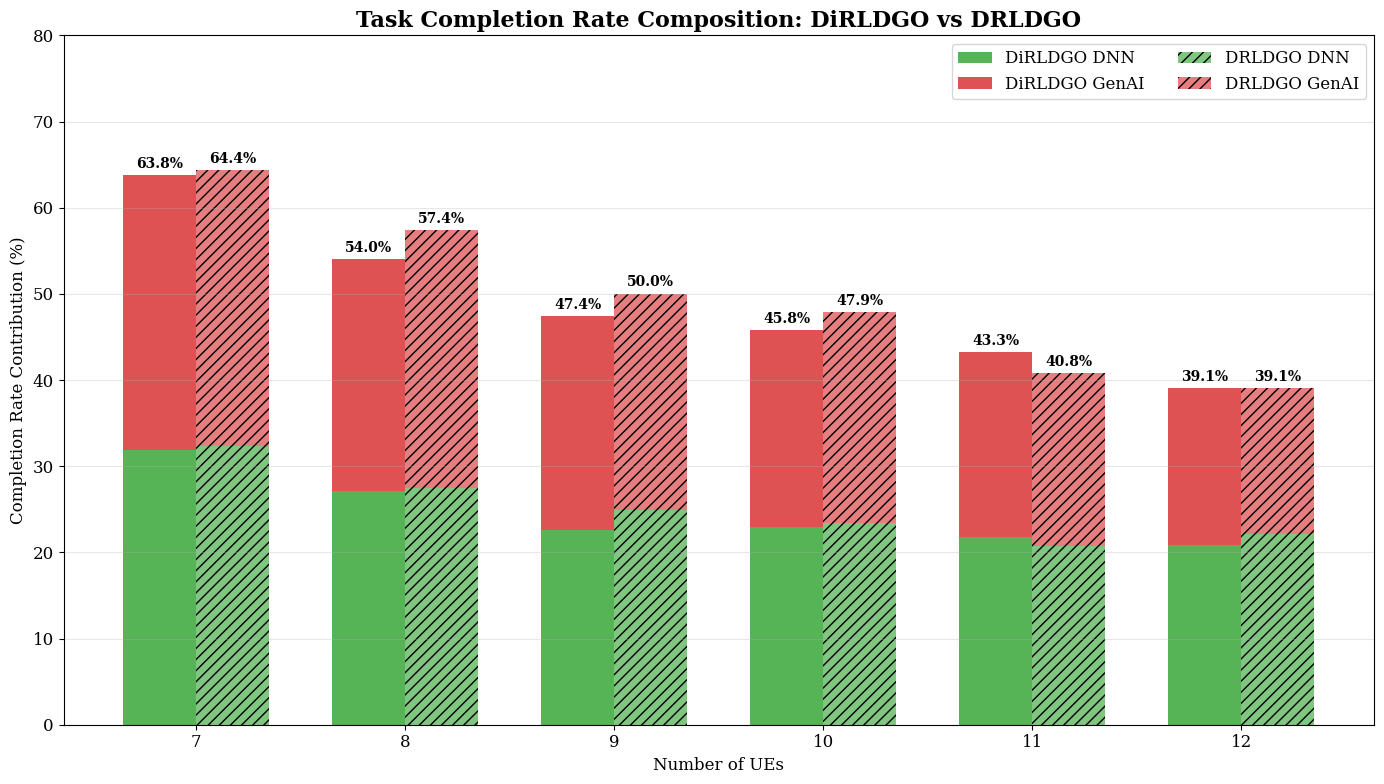


=== Side-by-Side Composition Comparison ===
Example interpretation: For 7 UEs, DiRLDGO achieves 63.8% total completion
  - 31.8% from DNN tasks, 32.0% from GenAI tasks
While DRLDGO achieves 64.4% total completion
  - 32.4% from DNN tasks, 32.0% from GenAI tasks


In [16]:
def plot_completion_comparison_stacked(dql_task_metrics, gdql_task_metrics, start_epoch=401, end_epoch=500):
    """Plot side-by-side stacked bars comparing DiRLDGO vs DRLDGO completion composition"""
    
    import numpy as np
    
    # UE configurations and display numbers
    ue_configs = ['7_ues', '8_ues', '9_ues', '10_ues', '11_ues', '12_ues']
    ue_display = [7, 8, 9, 10, 11, 12]
    
    # Extract data (same calculation as above)
    dql_dnn = []
    dql_genai = []
    gdql_dnn = []
    gdql_genai = []
    
    for ue_config in ue_configs:
        # DiRLDGO data
        if ue_config in dql_task_metrics:
            metrics = dql_task_metrics[ue_config]
            total_tasks = metrics['total_tasks']
            
            if total_tasks > 0:
                dnn_weight = metrics['dnn_tasks'] / total_tasks
                genai_weight = metrics['genai_tasks'] / total_tasks
                
                dnn_contrib = dnn_weight * metrics['dnn_completion_rate'] * 100
                genai_contrib = genai_weight * metrics['genai_completion_rate'] * 100
            else:
                dnn_contrib = genai_contrib = 0
                
            dql_dnn.append(dnn_contrib)
            dql_genai.append(genai_contrib)
        else:
            dql_dnn.append(0)
            dql_genai.append(0)
            
        # DRLDGO data
        if ue_config in gdql_task_metrics:
            metrics = gdql_task_metrics[ue_config]
            total_tasks = metrics['total_tasks']
            
            if total_tasks > 0:
                dnn_weight = metrics['dnn_tasks'] / total_tasks
                genai_weight = metrics['genai_tasks'] / total_tasks
                
                dnn_contrib = dnn_weight * metrics['dnn_completion_rate'] * 100
                genai_contrib = genai_weight * metrics['genai_completion_rate'] * 100
            else:
                dnn_contrib = genai_contrib = 0
                
            gdql_dnn.append(dnn_contrib)
            gdql_genai.append(genai_contrib)
        else:
            gdql_dnn.append(0)
            gdql_genai.append(0)
    
    # Create grouped stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Bar settings
    bar_width = 0.35
    x_pos = np.arange(len(ue_display))
    
    # Colors
    color_dnn = '#2ca02c'      # Green for DNN
    color_genai = '#d62728'    # Red for GenAI
    
    # DiRLDGO bars (left side)
    bars1_dnn = ax.bar(x_pos - bar_width/2, dql_dnn, bar_width, 
                       label='DiRLDGO DNN', color=color_dnn, alpha=0.8)
    bars1_genai = ax.bar(x_pos - bar_width/2, dql_genai, bar_width, 
                         bottom=dql_dnn, label='DiRLDGO GenAI', color=color_genai, alpha=0.8)
    
    # DRLDGO bars (right side)
    bars2_dnn = ax.bar(x_pos + bar_width/2, gdql_dnn, bar_width, 
                       label='DRLDGO DNN', color=color_dnn, alpha=0.6, hatch='///')
    bars2_genai = ax.bar(x_pos + bar_width/2, gdql_genai, bar_width, 
                         bottom=gdql_dnn, label='DRLDGO GenAI', color=color_genai, alpha=0.6, hatch='///')
    
    # Formatting
    ax.set_title('Task Completion Rate Composition: DiRLDGO vs DRLDGO', fontsize=16, fontweight='bold')
    ax.set_xlabel('Number of UEs', fontsize=12)
    ax.set_ylabel('Completion Rate Contribution (%)', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ue_display)
    ax.set_ylim(0, 80)
    ax.legend(ncol=2, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add total labels above each bar
    for i in range(len(ue_display)):
        # DiRLDGO total
        total_dql = dql_dnn[i] + dql_genai[i]
        if total_dql > 0:
            ax.annotate(f'{total_dql:.1f}%',
                       xy=(i - bar_width/2, total_dql),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # DRLDGO total
        total_gdql = gdql_dnn[i] + gdql_genai[i]
        if total_gdql > 0:
            ax.annotate(f'{total_gdql:.1f}%',
                       xy=(i + bar_width/2, total_gdql),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison table
    print(f"\n=== Side-by-Side Composition Comparison ===")
    print(f"Example interpretation: For 7 UEs, DiRLDGO achieves {dql_dnn[0] + dql_genai[0]:.1f}% total completion")
    print(f"  - {dql_dnn[0]:.1f}% from DNN tasks, {dql_genai[0]:.1f}% from GenAI tasks")
    print(f"While DRLDGO achieves {gdql_dnn[0] + gdql_genai[0]:.1f}% total completion")
    print(f"  - {gdql_dnn[0]:.1f}% from DNN tasks, {gdql_genai[0]:.1f}% from GenAI tasks")

# Create the side-by-side comparison
plot_completion_comparison_stacked(dql_task_metrics, gdql_task_metrics, START_EPOCH, END_EPOCH)

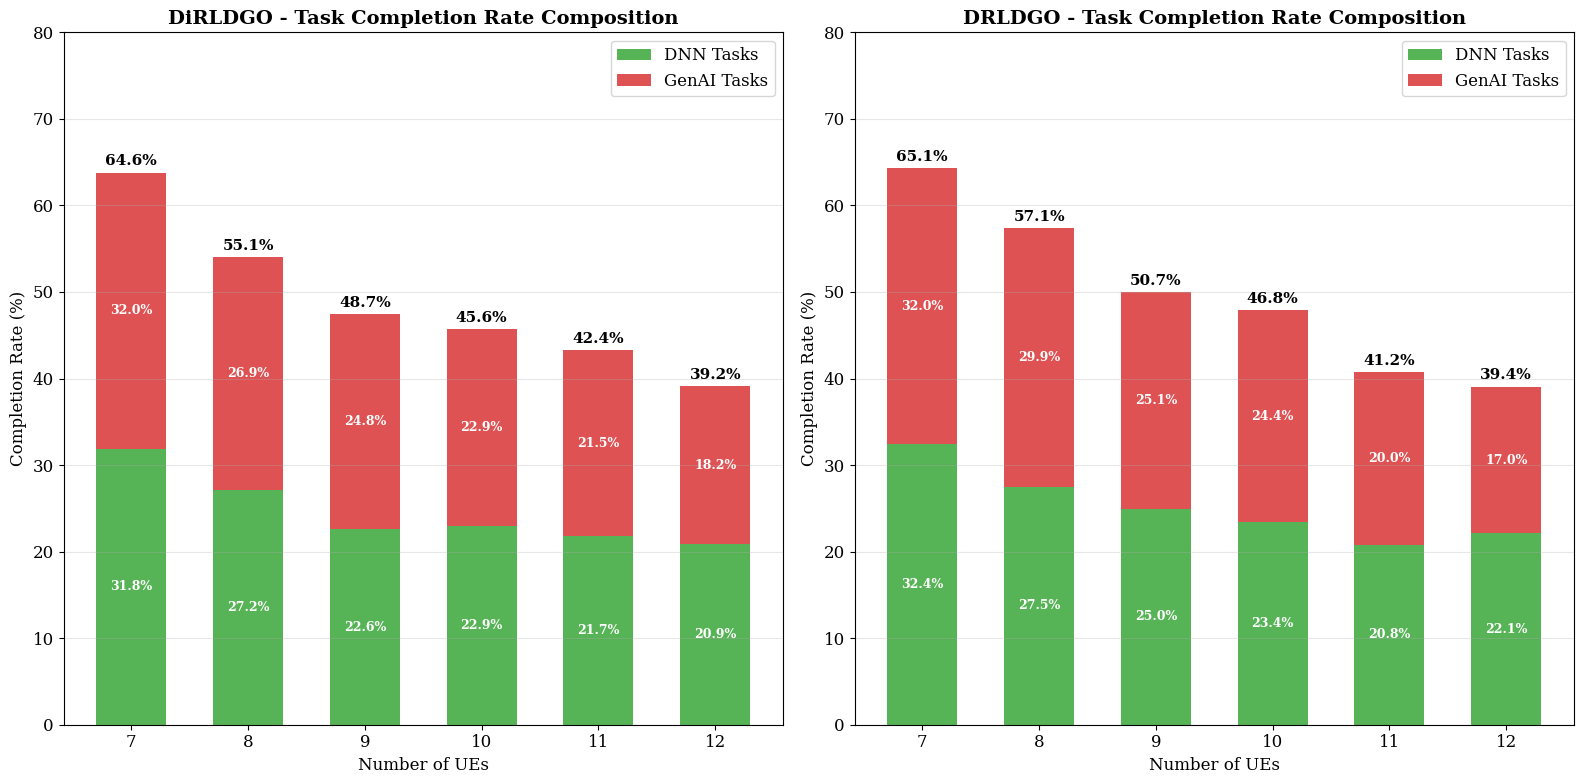


=== Task Completion Rate Composition Analysis (Epochs 401-500) ===
UE   Model    Total%   DNN%     GenAI%   DNN:GenAI   
------------------------------------------------------------
7    DiRLDGO  64.6     31.8     32.0     31.8:32.0   
7    DRLDGO   65.1     32.4     32.0     32.4:32.0   

8    DiRLDGO  55.1     27.2     26.9     27.2:26.9   
8    DRLDGO   57.1     27.5     29.9     27.5:29.9   

9    DiRLDGO  48.7     22.6     24.8     22.6:24.8   
9    DRLDGO   50.7     25.0     25.1     25.0:25.1   

10   DiRLDGO  45.6     22.9     22.9     22.9:22.9   
10   DRLDGO   46.8     23.4     24.4     23.4:24.4   

11   DiRLDGO  42.4     21.7     21.5     21.7:21.5   
11   DRLDGO   41.2     20.8     20.0     20.8:20.0   

12   DiRLDGO  39.2     20.9     18.2     20.9:18.2   
12   DRLDGO   39.4     22.1     17.0     22.1:17.0   



In [17]:
def plot_completion_rate_composition(dql_task_metrics, gdql_task_metrics, start_epoch=401, end_epoch=500):
    """Plot completion rate composition showing DNN vs GenAI contribution as stacked bars"""
    
    import numpy as np
    
    # UE configurations and display numbers
    ue_configs = ['7_ues', '8_ues', '9_ues', '10_ues', '11_ues', '12_ues']
    ue_display = [7, 8, 9, 10, 11, 12]
    
    # Extract completion rate composition data
    dql_data = {
        'dnn_contribution': [],
        'genai_contribution': [],
        'total_completion': []
    }
    
    gdql_data = {
        'dnn_contribution': [],
        'genai_contribution': [],
        'total_completion': []
    }
    
    # Calculate weighted contributions for each UE configuration
    for ue_config in ue_configs:
        # DiRLDGO data
        if ue_config in dql_task_metrics:
            metrics = dql_task_metrics[ue_config]
            total_tasks = metrics['total_tasks']
            dnn_tasks = metrics['dnn_tasks']
            genai_tasks = metrics['genai_tasks']
            
            # Calculate the contribution of each task type to overall completion
            # Contribution = (task_count / total_tasks) * completion_rate * overall_completion_rate
            total_completion = metrics['completion_rate'] * 100
            
            if total_tasks > 0:
                dnn_weight = dnn_tasks / total_tasks
                genai_weight = genai_tasks / total_tasks
                
                dnn_contribution = dnn_weight * metrics['dnn_completion_rate'] * 100
                genai_contribution = genai_weight * metrics['genai_completion_rate'] * 100
            else:
                dnn_contribution = 0
                genai_contribution = 0
            
            dql_data['dnn_contribution'].append(dnn_contribution)
            dql_data['genai_contribution'].append(genai_contribution)
            dql_data['total_completion'].append(total_completion)
        else:
            dql_data['dnn_contribution'].append(0)
            dql_data['genai_contribution'].append(0)
            dql_data['total_completion'].append(0)
            
        # DRLDGO data
        if ue_config in gdql_task_metrics:
            metrics = gdql_task_metrics[ue_config]
            total_tasks = metrics['total_tasks']
            dnn_tasks = metrics['dnn_tasks']
            genai_tasks = metrics['genai_tasks']
            
            total_completion = metrics['completion_rate'] * 100
            
            if total_tasks > 0:
                dnn_weight = dnn_tasks / total_tasks
                genai_weight = genai_tasks / total_tasks
                
                dnn_contribution = dnn_weight * metrics['dnn_completion_rate'] * 100
                genai_contribution = genai_weight * metrics['genai_completion_rate'] * 100
            else:
                dnn_contribution = 0
                genai_contribution = 0
            
            gdql_data['dnn_contribution'].append(dnn_contribution)
            gdql_data['genai_contribution'].append(genai_contribution)
            gdql_data['total_completion'].append(total_completion)
        else:
            gdql_data['dnn_contribution'].append(0)
            gdql_data['genai_contribution'].append(0)
            gdql_data['total_completion'].append(0)
    
    # Create figure with stacked bar charts
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar width and positions
    bar_width = 0.6
    x_pos = np.arange(len(ue_display))
    
    # Colors for DNN and GenAI
    color_dnn = '#2ca02c'      # Green for DNN
    color_genai = '#d62728'    # Red for GenAI
    
    # Plot 1: DiRLDGO Stacked Bar
    bars1_dnn = ax1.bar(x_pos, dql_data['dnn_contribution'], bar_width, 
                        label='DNN Tasks', color=color_dnn, alpha=0.8)
    bars1_genai = ax1.bar(x_pos, dql_data['genai_contribution'], bar_width, 
                          bottom=dql_data['dnn_contribution'], 
                          label='GenAI Tasks', color=color_genai, alpha=0.8)
    
    ax1.set_title('DiRLDGO - Task Completion Rate Composition', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of UEs', fontsize=12)
    ax1.set_ylabel('Completion Rate (%)', fontsize=12)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(ue_display)
    ax1.set_ylim(0, 80)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add total completion rate labels on top of stacked bars
    for i, (dnn, genai, total) in enumerate(zip(dql_data['dnn_contribution'], 
                                                dql_data['genai_contribution'], 
                                                dql_data['total_completion'])):
        if total > 0:
            ax1.annotate(f'{total:.1f}%',
                        xy=(i, dnn + genai),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=11, fontweight='bold')
            
            # Add individual component labels if they're significant enough
            if dnn > 5:  # Only show label if contribution > 5%
                ax1.annotate(f'{dnn:.1f}%',
                            xy=(i, dnn/2),
                            ha='center', va='center', fontsize=9, color='white', fontweight='bold')
            if genai > 5:
                ax1.annotate(f'{genai:.1f}%',
                            xy=(i, dnn + genai/2),
                            ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    
    # Plot 2: DRLDGO Stacked Bar
    bars2_dnn = ax2.bar(x_pos, gdql_data['dnn_contribution'], bar_width, 
                        label='DNN Tasks', color=color_dnn, alpha=0.8)
    bars2_genai = ax2.bar(x_pos, gdql_data['genai_contribution'], bar_width, 
                          bottom=gdql_data['dnn_contribution'], 
                          label='GenAI Tasks', color=color_genai, alpha=0.8)
    
    ax2.set_title('DRLDGO - Task Completion Rate Composition', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of UEs', fontsize=12)
    ax2.set_ylabel('Completion Rate (%)', fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(ue_display)
    ax2.set_ylim(0, 80)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add total completion rate labels on top of stacked bars
    for i, (dnn, genai, total) in enumerate(zip(gdql_data['dnn_contribution'], 
                                                gdql_data['genai_contribution'], 
                                                gdql_data['total_completion'])):
        if total > 0:
            ax2.annotate(f'{total:.1f}%',
                        xy=(i, dnn + genai),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=11, fontweight='bold')
            
            # Add individual component labels if they're significant enough
            if dnn > 5:
                ax2.annotate(f'{dnn:.1f}%',
                            xy=(i, dnn/2),
                            ha='center', va='center', fontsize=9, color='white', fontweight='bold')
            if genai > 5:
                ax2.annotate(f'{genai:.1f}%',
                            xy=(i, dnn + genai/2),
                            ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed breakdown
    print(f"\n=== Task Completion Rate Composition Analysis (Epochs {start_epoch}-{end_epoch}) ===")
    print(f"{'UE':<4} {'Model':<8} {'Total%':<8} {'DNN%':<8} {'GenAI%':<8} {'DNN:GenAI':<12}")
    print("-" * 60)
    
    for i, ue_config in enumerate(ue_configs):
        ue_num = ue_display[i]
        
        if ue_config in dql_task_metrics:
            total = dql_data['total_completion'][i]
            dnn = dql_data['dnn_contribution'][i]
            genai = dql_data['genai_contribution'][i]
            ratio = f"{dnn:.1f}:{genai:.1f}" if genai > 0 else f"{dnn:.1f}:0"
            
            print(f"{ue_num:<4} {'DiRLDGO':<8} {total:<8.1f} {dnn:<8.1f} {genai:<8.1f} {ratio:<12}")
        
        if ue_config in gdql_task_metrics:
            total = gdql_data['total_completion'][i]
            dnn = gdql_data['dnn_contribution'][i]
            genai = gdql_data['genai_contribution'][i]
            ratio = f"{dnn:.1f}:{genai:.1f}" if genai > 0 else f"{dnn:.1f}:0"
            
            print(f"{ue_num:<4} {'DRLDGO':<8} {total:<8.1f} {dnn:<8.1f} {genai:<8.1f} {ratio:<12}")
        print()

# Create the composition chart
plot_completion_rate_composition(dql_task_metrics, gdql_task_metrics, START_EPOCH, END_EPOCH)

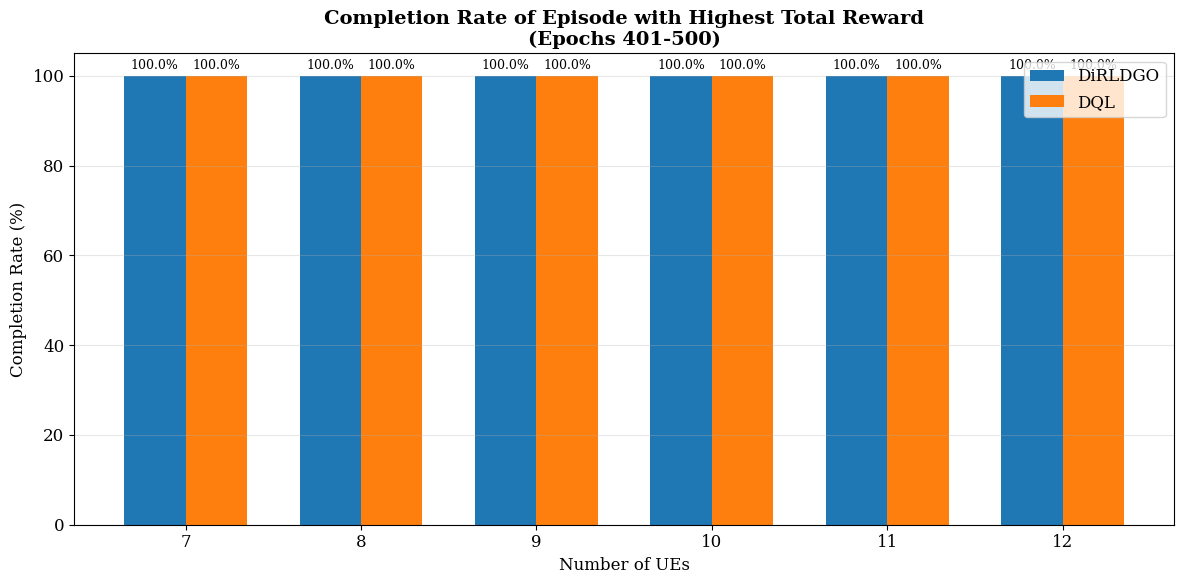


=== Best Episode Selection (by total reward) ===
UE   Model   Epoch  Episode  FinalStep  CompRate%  TotalReward 
----------------------------------------------------------------------
7    DiRLDGO 472    3        25         100.0      2853.99     
7    DQL     466    4        29         100.0      3204.99     

8    DiRLDGO 450    2        26         100.0      3274.23     
8    DQL     483    4        27         100.0      3607.99     

9    DiRLDGO 419    3        33         100.0      4491.70     
9    DQL     443    1        29         100.0      3932.03     

10   DiRLDGO 487    0        31         100.0      4824.99     
10   DQL     469    3        32         100.0      4447.63     

11   DiRLDGO 482    2        37         100.0      5510.13     
11   DQL     445    0        38         100.0      6110.59     

12   DiRLDGO 412    1        35         100.0      6323.96     
12   DQL     472    1        41         100.0      7115.46     



In [18]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Find, for each UE config, the episode with the highest total reward (sum of per-step rewards)
# within the configured epoch window, then take that episode's final-step completion rate.
def find_best_episode_completion_rates(model_paths, start_epoch, end_epoch):
    best_by_ue = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        if not os.path.exists(step_metrics_file):
            continue
        try:
            with open(step_metrics_file, 'r') as f:
                step_metrics = json.load(f)
        except Exception:
            continue
        
        # Aggregate per (epoch, episode)
        episode_data = {}
        for entry in step_metrics:
            epoch = entry.get('epoch')
            episode = entry.get('episode')
            step = entry.get('step')
            if epoch is None or episode is None or step is None:
                continue
            if epoch < start_epoch or epoch > end_epoch:
                continue
            key = (epoch, episode)
            if key not in episode_data:
                episode_data[key] = {
                    'total_reward': 0.0,
                    'max_step': -1,
                    'last_entry': None,
                }
            reward_val = entry.get('reward', 0.0) or 0.0
            try:
                reward_val = float(reward_val)
            except Exception:
                reward_val = 0.0
            episode_data[key]['total_reward'] += reward_val
            if step > episode_data[key]['max_step']:
                episode_data[key]['max_step'] = step
                episode_data[key]['last_entry'] = entry
        
        if not episode_data:
            continue
        
        # Pick the episode with the highest total reward; tie-breaker by later epoch
        best_key, best_info = max(
            episode_data.items(), key=lambda kv: (kv[1]['total_reward'], kv[0][0])
        )
        best_epoch, best_episode = best_key
        last_entry = best_info['last_entry'] or {}
        completion_rate = last_entry.get('completion_rate', 0.0) or 0.0  # 0..1
        best_by_ue[ue_name] = {
            'epoch': best_epoch,
            'episode': best_episode,
            'total_reward': best_info['total_reward'],
            'final_step': best_info['max_step'],
            'completion_rate': float(completion_rate) * 100.0,  # percent
        }
    
    return best_by_ue

# Compute best-episode completion rates for both DiffQL and DQL within the selected window
best_dql = find_best_episode_completion_rates(dql_paths, START_EPOCH, END_EPOCH)
best_gdql = find_best_episode_completion_rates(gdql_paths, START_EPOCH, END_EPOCH)

# Prepare data for plotting (ordered by UE count)
ue_configs_order = ['7_ues', '8_ues', '9_ues', '10_ues', '11_ues', '12_ues']
ue_display = [7, 8, 9, 10, 11, 12]

dql_rates = []
gdql_rates = []
for ue_key in ue_configs_order:
    dql_rates.append(best_dql.get(ue_key, {}).get('completion_rate', 0.0))
    gdql_rates.append(best_gdql.get(ue_key, {}).get('completion_rate', 0.0))

# Plot grouped bar chart
x = np.arange(len(ue_display))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - bar_width/2, dql_rates, bar_width, label='DiRLDGO', color='#1f77b4')
rects2 = ax.bar(x + bar_width/2, gdql_rates, bar_width, label='DQL', color='#ff7f0e')

ax.set_title(f'Completion Rate of Episode with Highest Total Reward\n(Epochs {START_EPOCH}-{END_EPOCH})', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of UEs')
ax.set_ylabel('Completion Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(ue_display)
ax.set_ylim(0, 105)
ax.grid(True, axis='y', alpha=0.3)
ax.legend()

# Add value labels
for rects in (rects1, rects2):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print a concise table of selections
print("\n=== Best Episode Selection (by total reward) ===")
print(f"{'UE':<4} {'Model':<7} {'Epoch':<6} {'Episode':<8} {'FinalStep':<10} {'CompRate%':<10} {'TotalReward':<12}")
print('-' * 70)
for i, ue_key in enumerate(ue_configs_order):
    ue_num = ue_display[i]
    if ue_key in best_dql:
        b = best_dql[ue_key]
        print(f"{ue_num:<4} {'DiRLDGO':<7} {b['epoch']:<6} {b['episode']:<8} {b['final_step']:<10} {b['completion_rate']:<10.1f} {b['total_reward']:<12.2f}")
    if ue_key in best_gdql:
        b = best_gdql[ue_key]
        print(f"{ue_num:<4} {'DQL':<7} {b['epoch']:<6} {b['episode']:<8} {b['final_step']:<10} {b['completion_rate']:<10.1f} {b['total_reward']:<12.2f}")
    if (ue_key in best_dql) or (ue_key in best_gdql):
        print() 



In [19]:
# Override with fallback contribution allocation when per-type rates are missing

def plot_completion_rate_barchart(epoch: int, episode: int, final_step: int,
                                  metric: str = "completion_rate") -> None:
    """
    Plot a grouped bar chart of a chosen completion metric at a specific (epoch, episode, step)
    for both DiffQL and DQL across UE counts.

    Parameters
    - epoch: target epoch (int)
    - episode: target episode (int)
    - final_step: target step (int)
    - metric: one of {"completion_rate", "genai_completion_rate", "dnn_completion_rate"}
    """
    assert metric in {"completion_rate", "genai_completion_rate", "dnn_completion_rate"}, (
        "metric must be one of {'completion_rate','genai_completion_rate','dnn_completion_rate'}"
    )

    ue_configs_order = ["7_ues", "8_ues", "9_ues", "10_ues", "11_ues", "12_ues"]
    ue_display = [7, 8, 9, 10, 11, 12]

    def collect_metric(model_paths):
        vals = {}
        for ue_config, path in model_paths.items():
            ue_name = ue_config.split("/")[0]
            step_metrics_file = os.path.join(path, "metrics", "step_metrics.json")
            if not os.path.exists(step_metrics_file):
                continue
            try:
                with open(step_metrics_file, "r") as f:
                    step_metrics = json.load(f)
            except Exception:
                continue

            found = False
            for entry in step_metrics:
                if (entry.get("epoch") == epoch
                        and entry.get("episode") == episode
                        and entry.get("step") == final_step):
                    v = entry.get(metric, 0.0) or 0.0
                    try:
                        vals[ue_name] = float(v) * 100.0  # percent
                    except Exception:
                        vals[ue_name] = 0.0
                    found = True
                    break
            if not found:
                vals[ue_name] = 0.0
        return vals

    dql_vals = collect_metric(dql_paths)
    gdql_vals = collect_metric(gdql_paths)

    # Align to order
    dql_rates = [dql_vals.get(k, 0.0) for k in ue_configs_order]
    gdql_rates = [gdql_vals.get(k, 0.0) for k in ue_configs_order]

    # Titles for metric
    metric_titles = {
        "completion_rate": "Overall Completion Rate",
        "genai_completion_rate": "GenAI Completion Rate",
        "dnn_completion_rate": "DNN Completion Rate",
    }

    x_pos = np.arange(len(ue_display))
    bar_width = 0.4  # narrower bars
    group_offset = 0.30  # space between DiffQL and DQL within each UE group

    # Helper to collect weighted contributions from DNN vs GenAI
    def collect_contribs(model_paths):
        dnn_contrib = []
        genai_contrib = []
        total_completion = []
        for ue_key in ue_configs_order:
            vals = {"dnn": 0.0, "genai": 0.0, "total": 0.0}
            # Find path even if dict keys include suffix like '7_ues/43'
            path = None
            for k, p in model_paths.items():
                if k.split('/') [0] == ue_key:
                    path = p
                    break
            if path:
                step_metrics_file = os.path.join(path, "metrics", "step_metrics.json")
                if os.path.exists(step_metrics_file):
                    try:
                        with open(step_metrics_file, "r") as f:
                            step_metrics = json.load(f)
                        for entry in step_metrics:
                            if (entry.get("epoch") == epoch and entry.get("episode") == episode and entry.get("step") == final_step):
                                total_tasks = (entry.get("total_dnn_ues", 0) or 0) + (entry.get("total_genai_ues", 0) or 0)
                                dnn_tasks = (entry.get('total_dnn_ues', 0) or 0)
                                genai_tasks = (entry.get('total_genai_ues', 0) or 0)
                                total = float(entry.get("completion_rate", 0.0) or 0.0) * 100.0
                                # Base per-type rates (percent)
                                dnn_rate = float(entry.get("dnn_completion_rate", 0.0) or 0.0) * 100.0
                                genai_rate = float(entry.get("genai_completion_rate", 0.0) or 0.0) * 100.0
                                if total_tasks > 0:
                                    dnn_w = dnn_tasks / total_tasks
                                    genai_w = genai_tasks / total_tasks
                                else:
                                    dnn_w = genai_w = 0.0
                                # Weighted contributions if rates available
                                dnn_v = dnn_w * dnn_rate
                                genai_v = genai_w * genai_rate
                                # Fallback: if both contributions are zero but total > 0, distribute by task ratio
                                if (dnn_v + genai_v) == 0 and total > 0 and total_tasks > 0:
                                    dnn_v = dnn_w * total
                                    genai_v = genai_w * total
                                vals = {"dnn": dnn_v, "genai": genai_v, "total": total}
                                break
                    except Exception:
                        pass
            dnn_contrib.append(vals["dnn"])
            genai_contrib.append(vals["genai"])
            total_completion.append(vals["total"])
        return dnn_contrib, genai_contrib, total_completion

    dql_dnn, dql_genai, dql_total = collect_contribs(dql_paths)
    gdql_dnn, gdql_genai, gdql_total = collect_contribs(gdql_paths)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    color_dnn = '#2ca02c'
    color_genai = '#d62728'

    # Left: DiffQL stacked bars
    bars1_dnn = ax1.bar(x_pos, dql_dnn, bar_width, color=color_dnn, alpha=0.8, label='DNN Tasks')
    bars1_genai = ax1.bar(x_pos, dql_genai, bar_width, bottom=dql_dnn, color=color_genai, alpha=0.8, label='GenAI Tasks')
    ax1.set_title(f"DiffQL - {metric_titles.get(metric, 'Completion Rate')}", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Number of UEs", fontsize=12)
    ax1.set_ylabel("Completion Rate (%)", fontsize=12)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(ue_display)
    ax1.set_ylim(0, 105)
    ax1.grid(True, alpha=0.3, axis="y")
    ax1.legend()

    for i, (dnn, genai, total) in enumerate(zip(dql_dnn, dql_genai, dql_total)):
        if total > 0:
            ax1.annotate(f"{total:.1f}%", xy=(i, dnn + genai), xytext=(0, 3), textcoords="offset points",
                         ha='center', va='bottom', fontsize=11, fontweight='bold')
            if dnn > 5:
                ax1.annotate(f"{dnn:.1f}%", xy=(i, dnn/2), ha='center', va='center', fontsize=9, color='white', fontweight='bold')
            if genai > 5:
                ax1.annotate(f"{genai:.1f}%", xy=(i, dnn + genai/2), ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    # Right: DQL stacked bars
    bars2_dnn = ax2.bar(x_pos, gdql_dnn, bar_width, color=color_dnn, alpha=0.8, label='DNN Tasks')
    bars2_genai = ax2.bar(x_pos, gdql_genai, bar_width, bottom=gdql_dnn, color=color_genai, alpha=0.8, label='GenAI Tasks')
    ax2.set_title(f"DQL - {metric_titles.get(metric, 'Completion Rate')}", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Number of UEs", fontsize=12)
    ax2.set_ylabel("Completion Rate (%)", fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(ue_display)
    ax2.set_ylim(0, 105)
    ax2.grid(True, alpha=0.3, axis="y")
    ax2.legend()

    for i, (dnn, genai, total) in enumerate(zip(gdql_dnn, gdql_genai, gdql_total)):
        if total > 0:
            ax2.annotate(f"{total:.1f}%", xy=(i, dnn + genai), xytext=(0, 3), textcoords="offset points",
                         ha='center', va='bottom', fontsize=10, fontweight='bold')
            if dnn > 5:
                ax2.annotate(f"{dnn:.1f}%", xy=(i, dnn/2), ha='center', va='center', fontsize=9, color='white', fontweight='bold')
            if genai > 5:
                ax2.annotate(f"{genai:.1f}%", xy=(i, dnn + genai/2), ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print table
    print("\n=== Selected Metric Table ===")
    print(f"{'UE':<4} {'Model':<7} {'Epoch':<6} {'Episode':<8} {'Step':<6} {'Metric':<22} {'Value%':<8}")
    print("-" * 80)
    for i, ue_key in enumerate(ue_configs_order):
        ue_num = ue_display[i]
        dv = dql_vals.get(ue_key, 0.0)
        gv = gdql_vals.get(ue_key, 0.0)
        print(f"{ue_num:<4} {'DiRLDGO':<7} {epoch:<6} {episode:<8} {final_step:<6} {metric:<22} {dv:<8.1f}")
        print(f"{ue_num:<4} {'DQL':<7} {epoch:<6} {episode:<8} {final_step:<6} {metric:<22} {gv:<8.1f}")
        print()


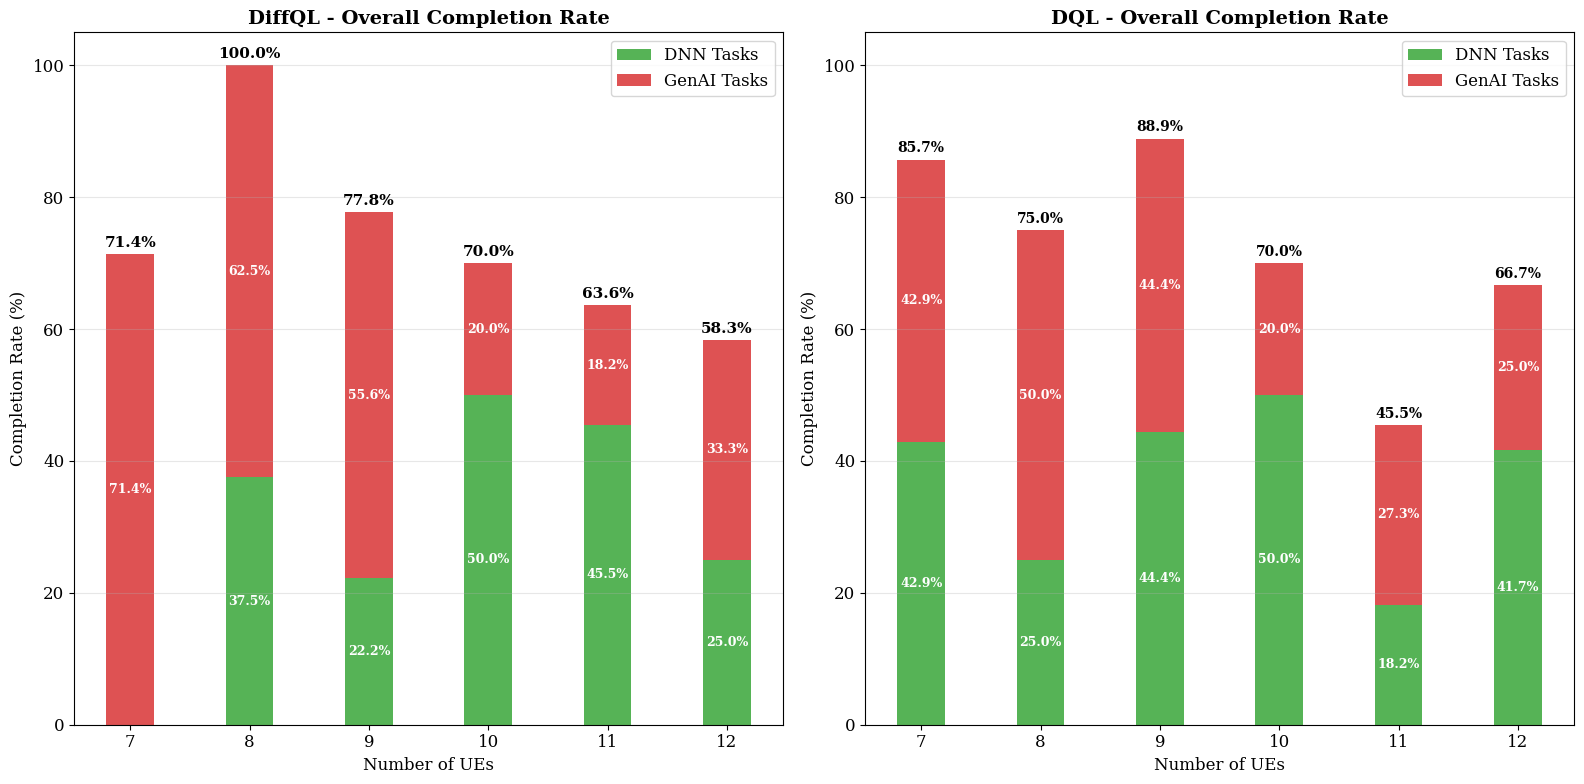


=== Selected Metric Table ===
UE   Model   Epoch  Episode  Step   Metric                 Value%  
--------------------------------------------------------------------------------
7    DiRLDGO 472    3        17     completion_rate        71.4    
7    DQL     472    3        17     completion_rate        85.7    

8    DiRLDGO 472    3        17     completion_rate        100.0   
8    DQL     472    3        17     completion_rate        75.0    

9    DiRLDGO 472    3        17     completion_rate        77.8    
9    DQL     472    3        17     completion_rate        88.9    

10   DiRLDGO 472    3        17     completion_rate        70.0    
10   DQL     472    3        17     completion_rate        70.0    

11   DiRLDGO 472    3        17     completion_rate        63.6    
11   DQL     472    3        17     completion_rate        45.5    

12   DiRLDGO 472    3        17     completion_rate        58.3    
12   DQL     472    3        17     completion_rate        66.7    

In [20]:

# Example usage (uncomment to run):
plot_completion_rate_barchart(epoch=472, episode=3, final_step=17, metric="completion_rate")



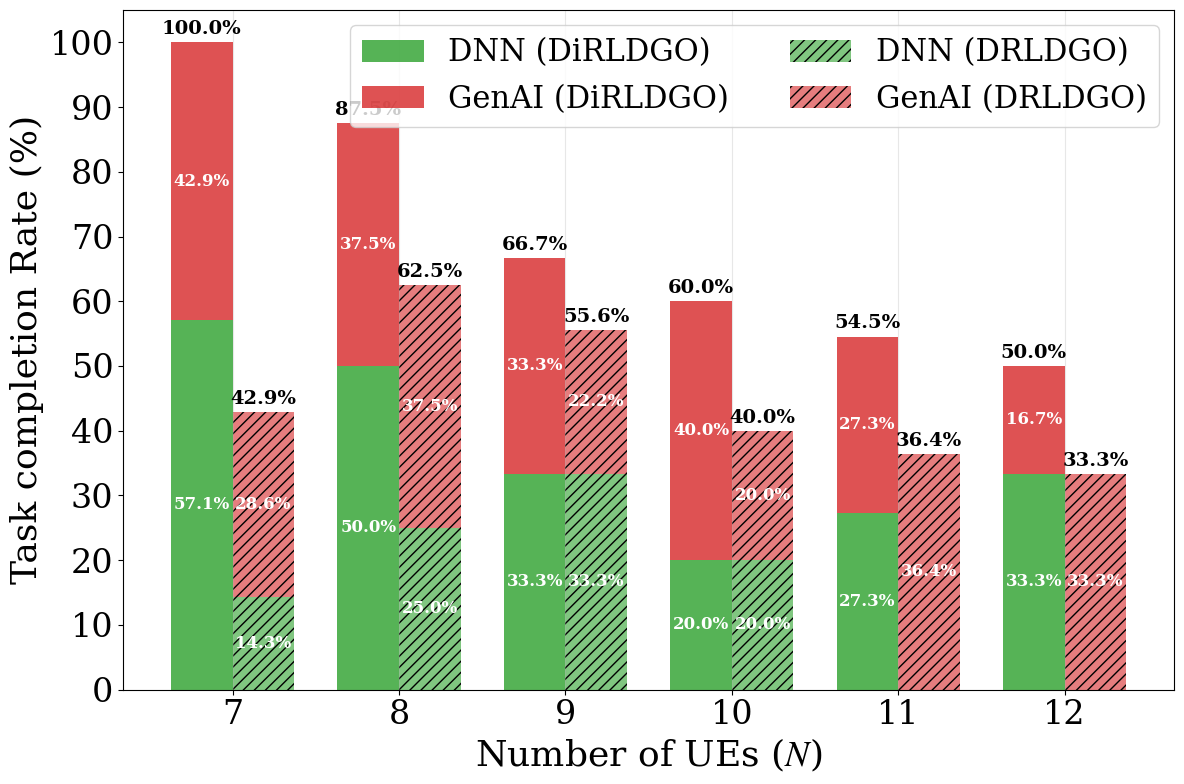

In [26]:
# Override with fallback contribution allocation when per-type rates are missing

def plot_completion_rate_barchart(epoch: int, episode: int, final_step: int,
                                  metric: str = "completion_rate") -> None:
    """
    Plot a grouped bar chart of a chosen completion metric at a specific (epoch, episode, step)
    for both DiffQL and DQL across UE counts.

    Parameters
    - epoch: target epoch (int)
    - episode: target episode (int)
    - final_step: target step (int)
    - metric: one of {"completion_rate", "genai_completion_rate", "dnn_completion_rate"}
    """
    assert metric in {"completion_rate", "genai_completion_rate", "dnn_completion_rate"}, (
        "metric must be one of {'completion_rate','genai_completion_rate','dnn_completion_rate'}"
    )

    ue_configs_order = ["7_ues", "8_ues", "9_ues", "10_ues", "11_ues", "12_ues"]
    ue_display = [7, 8, 9, 10, 11, 12]
    percents_display = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

    def collect_metric(model_paths):
        vals = {}
        for ue_config, path in model_paths.items():
            ue_name = ue_config.split("/")[0]
            step_metrics_file = os.path.join(path, "metrics", "step_metrics.json")
            if not os.path.exists(step_metrics_file):
                continue
            try:
                with open(step_metrics_file, "r") as f:
                    step_metrics = json.load(f)
            except Exception:
                continue

            found = False
            for entry in step_metrics:
                if (entry.get("epoch") == epoch
                        and entry.get("episode") == episode
                        and entry.get("step") == final_step):
                    v = entry.get(metric, 0.0) or 0.0
                    try:
                        vals[ue_name] = float(v) * 100.0  # percent
                    except Exception:
                        vals[ue_name] = 0.0
                    found = True
                    break
            if not found:
                vals[ue_name] = 0.0
        return vals

    dql_vals = collect_metric(dql_paths)
    gdql_vals = collect_metric(gdql_paths)

    # Align to order
    dql_rates = [dql_vals.get(k, 0.0) for k in ue_configs_order]
    gdql_rates = [gdql_vals.get(k, 0.0) for k in ue_configs_order]

    # Titles for metric
    metric_titles = {
        "completion_rate": "Overall Completion Rate",
        "genai_completion_rate": "GenAI Completion Rate",
        "dnn_completion_rate": "DNN Completion Rate",
    }

    x_pos = np.arange(len(ue_display))
    y_pos = np.arange(0, 110, 10)
    bar_width = 0.37

    # Helper to collect weighted contributions from DNN vs GenAI
    def collect_contribs(model_paths):
        dnn_contrib = []
        genai_contrib = []
        total_completion = []
        for ue_key in ue_configs_order:
            vals = {"dnn": 0.0, "genai": 0.0, "total": 0.0}
            # Find path even if dict keys include suffix like '7_ues/43'
            path = None
            for k, p in model_paths.items():
                if k.split('/') [0] == ue_key:
                    path = p
                    break
            if path:
                step_metrics_file = os.path.join(path, "metrics", "step_metrics.json")
                if os.path.exists(step_metrics_file):
                    try:
                        with open(step_metrics_file, "r") as f:
                            step_metrics = json.load(f)
                        for entry in step_metrics:
                            if (entry.get("epoch") == epoch and entry.get("episode") == episode and entry.get("step") == final_step):
                                total_tasks = (entry.get("total_dnn_ues", 0) or 0) + (entry.get("total_genai_ues", 0) or 0)
                                dnn_tasks = (entry.get('total_dnn_ues', 0) or 0)
                                genai_tasks = (entry.get('total_genai_ues', 0) or 0)
                                total = float(entry.get("completion_rate", 0.0) or 0.0) * 100.0
                                # Base per-type rates (percent)
                                dnn_rate = float(entry.get("dnn_completion_rate", 0.0) or 0.0) * 100.0
                                genai_rate = float(entry.get("genai_completion_rate", 0.0) or 0.0) * 100.0
                                if total_tasks > 0:
                                    dnn_w = dnn_tasks / total_tasks
                                    genai_w = genai_tasks / total_tasks
                                else:
                                    dnn_w = genai_w = 0.0
                                # Weighted contributions if rates available
                                dnn_v = dnn_w * dnn_rate
                                genai_v = genai_w * genai_rate
                                # Fallback: if both contributions are zero but total > 0, distribute by task ratio
                                if (dnn_v + genai_v) == 0 and total > 0 and total_tasks > 0:
                                    dnn_v = dnn_w * total
                                    genai_v = genai_w * total
                                vals = {"dnn": dnn_v, "genai": genai_v, "total": total}
                                break
                    except Exception:
                        pass
            dnn_contrib.append(vals["dnn"])
            genai_contrib.append(vals["genai"])
            total_completion.append(vals["total"])
        return dnn_contrib, genai_contrib, total_completion

    dql_dnn, dql_genai, dql_total = collect_contribs(dql_paths)
    gdql_dnn, gdql_genai, gdql_total = collect_contribs(gdql_paths)

    fig, ax = plt.subplots(figsize=(12, 8))

    color_dnn = '#2ca02c'
    color_genai = '#d62728'

    # Grouped stacked bars: left = DiffQL, right = DQL
    left = x_pos - bar_width/2
    right = x_pos + bar_width/2

    bars_dql_dnn = ax.bar(left, dql_dnn, bar_width, color=color_dnn, alpha=0.8, label='DNN (DiRLDGO)')
    bars_dql_genai = ax.bar(left, dql_genai, bar_width, bottom=dql_dnn, color=color_genai, alpha=0.8, label='GenAI (DiRLDGO)')

    bars_gdql_dnn = ax.bar(right, gdql_dnn, bar_width, color=color_dnn, alpha=0.6, hatch='///', label='DNN (DRLDGO)')
    bars_gdql_genai = ax.bar(right, gdql_genai, bar_width, bottom=gdql_dnn, color=color_genai, alpha=0.6, hatch='///', label='GenAI (DRLDGO)')

    # ax.set_title(f"{metric_titles.get(metric, 'Completion Rate')} Composition by UE — Epoch {epoch}, Episode {episode}, Step {final_step}", fontsize=14, fontweight='bold')
    ax.set_xlabel(r'Number of UEs ($N$)', fontsize=26)
    ax.set_ylabel('Task completion Rate (%)', fontsize=26)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ue_display, fontsize=24)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(percents_display, fontsize=24)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3, axis='x')
    ax.legend(ncol=2, loc='upper right', fontsize=22)

    # Totals above each stack
    for i in range(len(ue_display)):
        td = dql_dnn[i] + dql_genai[i]
        tg = gdql_dnn[i] + gdql_genai[i]
        if td > 0:
            ax.annotate(f'{td:.1f}%', xy=(left[i], td), xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=14, fontweight='bold')
        if tg > 0:
            ax.annotate(f'{tg:.1f}%', xy=(right[i], tg), xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=14, fontweight='bold')

    # Optional internal labels
    for i in range(len(ue_display)):
        if dql_dnn[i] > 5:
            ax.annotate(f'{dql_dnn[i]:.1f}%', xy=(left[i], dql_dnn[i]/2), ha='center', va='center', fontsize=12, color='white', fontweight='bold')
        if dql_genai[i] > 5:
            ax.annotate(f'{dql_genai[i]:.1f}%', xy=(left[i], dql_dnn[i] + dql_genai[i]/2), ha='center', va='center', fontsize=12, color='white', fontweight='bold')
        if gdql_dnn[i] > 5:
            ax.annotate(f'{gdql_dnn[i]:.1f}%', xy=(right[i], gdql_dnn[i]/2), ha='center', va='center', fontsize=12, color='white', fontweight='bold')
        if gdql_genai[i] > 5:
            ax.annotate(f'{gdql_genai[i]:.1f}%', xy=(right[i], gdql_dnn[i] + gdql_genai[i]/2), ha='center', va='center', fontsize=12, color='white', fontweight='bold')

    plt.tight_layout()
    # plt.grid()
    plt.show()


    # # Print table
    # print("\n=== Selected Metric Table ===")
    # print(f"{'UE':<4} {'Model':<7} {'Epoch':<6} {'Episode':<8} {'Step':<6} {'Metric':<22} {'Value%':<8}")
    # print("-" * 80)
    # for i, ue_key in enumerate(ue_configs_order):
    #     ue_num = ue_display[i]
    #     dv = dql_vals.get(ue_key, 0.0)
    #     gv = gdql_vals.get(ue_key, 0.0)
    #     print(f"{ue_num:<4} {'DiRLDGO':<7} {epoch:<6} {episode:<8} {final_step:<6} {metric:<22} {dv:<8.1f}")
    #     print(f"{ue_num:<4} {'DQL':<7} {epoch:<6} {episode:<8} {final_step:<6} {metric:<22} {gv:<8.1f}")
    #     print()

plot_completion_rate_barchart(epoch=35, episode=2, final_step=13, metric="completion_rate")


In [22]:

# Example usage (uncomment to run):



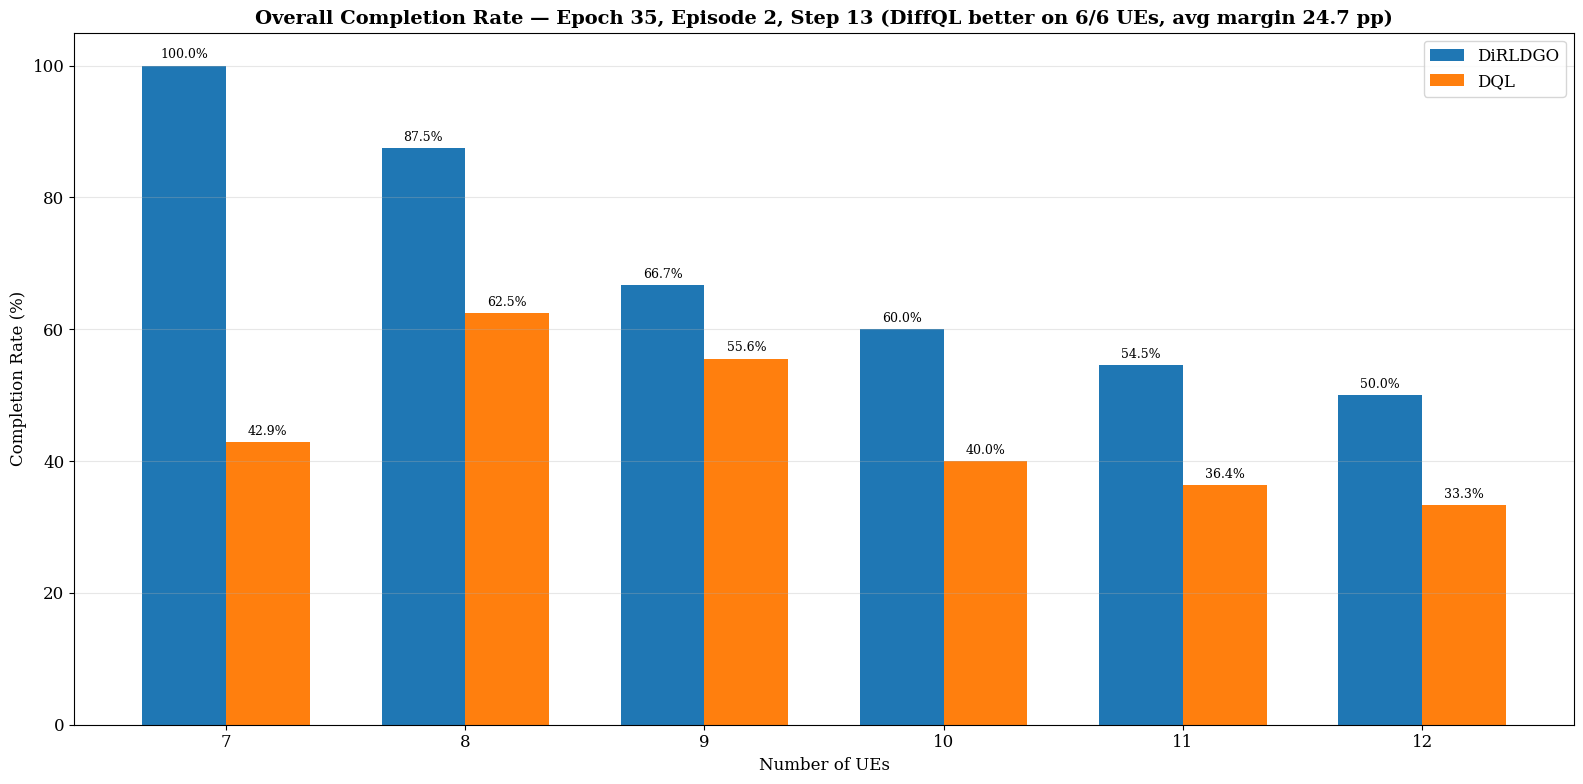


=== Selected Triple Where DiffQL Outperforms DQL (as much as possible) ===
Triple: epoch=35, episode=2, step=13
Coverage: 6/6 UEs, Better: 6/6 UEs, Avg margin: 24.68 pp
UE   DiffQL%    DQL%     Diff(pp) 
------------------------------------
7    100.0      42.9     57.1     
8    87.5       62.5     25.0     
9    66.7       55.6     11.1     
10   60.0       40.0     20.0     
11   54.5       36.4     18.2     
12   50.0       33.3     16.7     


In [23]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt


def plot_where_diffql_better_all_ues() -> None:
    """
    Find a single (epoch, episode, step) triple where DiffQL's completion_rate
    is higher than DQL's across ALL UE configs (7-12). If none exists, fall back to
    the triple that covers the most UEs with the largest average margin.

    Then plot a grouped bar chart (DiffQL vs DQL) per UE at that triple and print a table.
    """
    ue_configs_order = ["7_ues", "8_ues", "9_ues", "10_ues", "11_ues", "12_ues"]
    ue_display = [7, 8, 9, 10, 11, 12]

    def normalize_model_paths(model_paths: dict) -> dict:
        base = {}
        for k, p in model_paths.items():
            base_key = k.split('/')[0]
            if base_key not in base:
                base[base_key] = p
        return base

    def load_triples(base_paths: dict) -> dict:
        triples_by_ue = {}
        for ue_key in ue_configs_order:
            triples = {}
            path = base_paths.get(ue_key)
            if path:
                step_metrics_file = os.path.join(path, "metrics", "step_metrics.json")
                if os.path.exists(step_metrics_file):
                    try:
                        with open(step_metrics_file, "r") as f:
                            step_metrics = json.load(f)
                        for e in step_metrics:
                            epoch = e.get("epoch")
                            episode = e.get("episode")
                            step = e.get("step")
                            if epoch is None or episode is None or step is None:
                                continue
                            triple = (epoch, episode, step)
                            rate = float(e.get("completion_rate", 0.0) or 0.0) * 100.0
                            triples[triple] = rate
                    except Exception:
                        pass
            triples_by_ue[ue_key] = triples
        return triples_by_ue

    dql_base_paths = normalize_model_paths(dql_paths)
    gdql_base_paths = normalize_model_paths(gdql_paths)

    dql_triples = load_triples(dql_base_paths)
    gdql_triples = load_triples(gdql_base_paths)

    # Find triples present for BOTH models for ALL UEs
    common_triples = None
    for ue_key in ue_configs_order:
        both = set(dql_triples[ue_key].keys()) & set(gdql_triples[ue_key].keys())
        common_triples = set(both) if common_triples is None else (common_triples & both)

    def score_triple(triple) -> tuple:
        # returns: (num_present, num_better, avg_margin, per_ue)
        per_ue = {}
        present = 0
        better = 0
        margins = []
        for ue_key in ue_configs_order:
            dql_has = triple in dql_triples[ue_key]
            gdql_has = triple in gdql_triples[ue_key]
            if dql_has and gdql_has:
                present += 1
                dv = dql_triples[ue_key][triple]
                gv = gdql_triples[ue_key][triple]
                margin = dv - gv
                margins.append(margin)
                per_ue[ue_key] = (dv, gv, margin)
                if margin > 0:
                    better += 1
            else:
                per_ue[ue_key] = (None, None, None)
        avg_margin = float(np.mean(margins)) if margins else -1e9
        return present, better, avg_margin, per_ue

    selected_triple = None
    selected_stats = None

    # First preference: a triple with presence across ALL UEs and DiffQL > DQL for ALL UEs
    candidates = []
    if common_triples:
        for t in common_triples:
            present, better, avg_margin, per_ue = score_triple(t)
            if present == len(ue_configs_order) and better == len(ue_configs_order):
                candidates.append((avg_margin, t, per_ue))
    if candidates:
        candidates.sort(reverse=True)  # max avg margin first
        selected_triple = candidates[0][1]
        # recompute full stats for printing
        selected_stats = score_triple(selected_triple)
    else:
        # Fallback: scan all triples seen anywhere and pick the one with
        # highest (better, present, avg_margin)
        all_triples = set()
        for ue_key in ue_configs_order:
            all_triples |= set(dql_triples[ue_key].keys())
            all_triples |= set(gdql_triples[ue_key].keys())
        best_key = None
        best_tuple = (-1, -1, -1e9)  # better, present, avg_margin
        best_stats = None
        for t in all_triples:
            present, better, avg_margin, per_ue = score_triple(t)
            key = (better, present, avg_margin)
            if key > best_tuple:
                best_tuple = key
                best_key = t
                best_stats = (present, better, avg_margin, per_ue)
        selected_triple = best_key
        selected_stats = best_stats

    if selected_triple is None or selected_stats is None:
        print("No suitable triple found to compare DiffQL vs DQL.")
        return

    epoch, episode, step = selected_triple
    present, better, avg_margin, per_ue = selected_stats

    # Build series for plotting
    dql_rates = []
    gdql_rates = []
    for ue_key in ue_configs_order:
        dv, gv, _ = per_ue.get(ue_key, (None, None, None))
        dql_rates.append(dv if dv is not None else 0.0)
        gdql_rates.append(gv if gv is not None else 0.0)

    x = np.arange(len(ue_display))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(16, 8))
    rects1 = ax.bar(x - bar_width/2, dql_rates, bar_width, label='DiRLDGO', color='#1f77b4')
    rects2 = ax.bar(x + bar_width/2, gdql_rates, bar_width, label='DQL', color='#ff7f0e')

    title_prefix = "Overall Completion Rate"
    suffix = f"— Epoch {epoch}, Episode {episode}, Step {step}"
    status = f" (DiffQL better on {better}/{len(ue_display)} UEs, avg margin {avg_margin:.1f} pp)"
    ax.set_title(f"{title_prefix} {suffix}{status}", fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of UEs')
    ax.set_ylabel('Completion Rate (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(ue_display)
    ax.set_ylim(0, 105)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()

    # Value labels
    for rects in (rects1, rects2):
        for rect in rects:
            h = rect.get_height()
            if h > 0:
                ax.annotate(f'{h:.1f}%',
                            xy=(rect.get_x() + rect.get_width()/2, h),
                            xytext=(0, 3), textcoords='offset points',
                            ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Print table
    print("\n=== Selected Triple Where DiffQL Outperforms DQL (as much as possible) ===")
    print(f"Triple: epoch={epoch}, episode={episode}, step={step}")
    print(f"Coverage: {present}/{len(ue_display)} UEs, Better: {better}/{len(ue_display)} UEs, Avg margin: {avg_margin:.2f} pp")
    print(f"{'UE':<4} {'DiffQL%':<10} {'DQL%':<8} {'Diff(pp)':<9}")
    print('-' * 36)
    for i, ue_key in enumerate(ue_configs_order):
        ue_num = ue_display[i]
        dv, gv, mg = per_ue.get(ue_key, (None, None, None))
        if dv is None or gv is None:
            print(f"{ue_num:<4} {'-':<10} {'-':<8} {'-':<9}")
        else:
            print(f"{ue_num:<4} {dv:<10.1f} {gv:<8.1f} {mg:<9.1f}")

# Example run
plot_where_diffql_better_all_ues()

